# Содержание

* [1-Обзор данных](#1)
* [2-Предобработка данных](#2)
  * [2.1-Переименование столбцов](#2.1)
  * [2.2-Изменение типов данных](#2.2)
  * [2.3-Обработка явных дубликатов](#2.3)
  * [2.4-Обработка неявных дубликатов](#2.4)
* [3-Исследовательский анализ данных](#3)
  * [3.1-Статистический анализ данных в market_file](#3.1)
  * [3.2-Статистический анализ данных в market_money](#3.2)
  * [3.3-Статистический анализ данных в market_time](#3.3)
  * [3.4-Статистический анализ данных в money](#3.4)
  * [3.5-Объединение таблиц](#3.5)
* [4-Корреляционный анализ признаков](#4)
* [5-Обучение прогнозных моделей](#5)
  * [5.1-Создание пайплайна](#5.1)
  * [5.2-Обучение моделей](#5.2)
  * [5.3-Анализ важности признаков](#5.3)
* [6-Сегментация покупателей](#6)
* [7-Общий вывод](#7)

# Обучение с учителем: качество модели

**Цель исследования** — разработать решение, которое позволит персонализировать предложения постоянным клиентам интернет-магазина «В один клик», чтобы увеличить их покупательскую активность.

**Для этого:**

1. Построим модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца;

2. Включим в исследование дополнительные данные финансового департамента о прибыльности клиента: какой доход каждый покупатель приносил компании за последние три месяца;

3. Выделим сегменты покупателей, используя данные модели и данные о прибыльности клиентов. Разработаем персонализированные предложения для покупателей.

**Описание данных**

Данные для работы находятся в четырёх таблицах: `market_file.csv`, `market_money.csv`, `market_time.csv`, `money.csv`

**1.** `market_file.csv` содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении:


* `id` — номер покупателя в корпоративной базе данных;


* `Покупательская активность` — рассчитанный класс покупательской активности (целевой признак): `«снизилась»` или `«прежний уровень»`;


* `Тип сервиса` — уровень сервиса, например `«премиум»` и `«стандарт»`;


* `Разрешить сообщать` — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель;


* `Маркет_актив_6_мес` — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента;


* `Маркет_актив_тек_мес` — количество маркетинговых коммуникаций в текущем месяце;


* `Длительность` — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте;


* `Акционные_покупки` — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев;


* `Популярная_категория` — самая популярная категория товаров у покупателя за последние 6 месяцев;


* `Средний_просмотр_категорий_за_визит` — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца;


* `Неоплаченные_продукты_штук_квартал` — общее число неоплаченных товаров в корзине за последние 3 месяца;


* `Ошибка_сервиса` — число сбоев, которые коснулись покупателя во время посещения сайта;


* `Страниц_за_визит` — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.


**2.** `market_money.csv` содержит данные о выручке, которую получает магазин с покупателя, т.е. сколько покупатель всего потратил за период взаимодействия с сайтом:


* `id` — номер покупателя в корпоративной базе данных;


* `Период` — название периода, во время которого зафиксирована выручка. Например, `'текущий_месяц'` или `'предыдущий_месяц'`;


* `Выручка` — сумма выручки за период.


**3.** `market_time.csv`содержит данные о времени в минутах, которое покупатель провёл на сайте в течение периода:


* `id` — номер покупателя в корпоративной базе данных;


* `Период` — название периода, во время которого зафиксировано общее время;


* `минут` — значение времени, проведённого на сайте, в минутах.


**4.** `money.csv` содержит данные о среднемесячной прибыли продавца за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю:


* `id` — номер покупателя в корпоративной базе данных;


* `Прибыль` — значение прибыли.


**Ход исследования**

Исследование пройдёт в 5 этапов:

1. Обзор данных.

Ознакомимся с основными характеристиками и структурой данных.

2. Предобработка данных.

Выявим и устраним возможные проблемы в данных.

3. Исследовательский анализ.

Проведём статистический анализ для выявления и устранения возможных выбросов и аномалий, а также корреляционный анализ для поиска взаимосвязей между признаками.

4. Обучение прогнозных моделей.

Создадим пайплайны и обучим 4 модели для классификации: `KNeighborsClassifier()`, `DecisionTreeClassifier()`, `LogisticRegression()` и `SVC()`.

5. Сегментация покупателей.

Используем результаты моделирования и выполним сегментацию покупателей.

<a name="1"></a>
## Обзор данных

Загрузим 4 CSV-файла в датафреймы pandas:

In [1]:
# импортируем библиотеки для анализа данных и визуализации
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import phik 
import shap

# обозначим константу 
# обозначим размер тестовой выборки, оставим 25% данных для теста, 75% - на обучение
RANDOM_STATE = 42
TEST_SIZE = 0.25

# импортируем классы для работы с пайплайном
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# импортируем дополнительные классы для преобразования данных
from sklearn.preprocessing import (
                        OneHotEncoder, 
                        OrdinalEncoder, 
                        StandardScaler, 
                        MinMaxScaler,
                        RobustScaler
)

# импортируем классы для обучения моделей 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# импортируем класс для перебора гиперпараметров
from sklearn.model_selection import GridSearchCV

# импортируем метрики для оценки моделей
from sklearn.metrics import (
                        roc_auc_score,
                        fbeta_score,
                        ConfusionMatrixDisplay,
                        confusion_matrix,
                        precision_score,
                        recall_score
)

In [2]:
# сохраним в переменные ссылки на датафреймы
# в последнем файле укажем знак-разделитель с помощью параметра sep
market_file = pd.read_csv('https://code.s3.yandex.net/datasets/market_file.csv')
market_money = pd.read_csv('https://code.s3.yandex.net/datasets/market_money.csv')
market_time = pd.read_csv('https://code.s3.yandex.net/datasets/market_time.csv')
money = pd.read_csv('https://code.s3.yandex.net/datasets/money.csv', sep=';')

Выведем первые строки каждого датафрейма и проверим, что данные в таблицах соответствуют описанию:

In [3]:
# выведем первые 20 строк датафрейма с помощью метода head()
market_file.head(20)

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2
5,215353,Снизилась,стандартт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4
6,215354,Снизилась,стандартт,да,5.1,3,431,0.23,Косметика и аксесуары,2,3,7,2
7,215355,Снизилась,стандартт,нет,4.7,4,284,0.17,Товары для детей,5,1,6,4
8,215356,Снизилась,стандартт,да,4.2,4,192,0.14,Косметика и аксесуары,2,2,1,3
9,215357,Снизилась,стандартт,да,3.9,5,154,0.00,Техника для красоты и здоровья,3,3,9,5


In [4]:
# выведем первые 20 строк датафрейма с помощью метода head()
market_money.head(20)

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6
5,215349,предыдущий_месяц,5216.0
6,215350,препредыдущий_месяц,4826.0
7,215350,текущий_месяц,5058.4
8,215350,предыдущий_месяц,5457.5
9,215351,текущий_месяц,6610.4


In [5]:
# выведем первые 20 строк датафрейма с помощью метода head()
market_time.head(20)

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13
5,215350,предыдцщий_месяц,8
6,215351,текущий_месяц,13
7,215351,предыдцщий_месяц,11
8,215352,текущий_месяц,11
9,215352,предыдцщий_месяц,8


In [6]:
# выведем первые 20 строк датафрейма с помощью метода head()
money.head(20)

,id,Прибыль
0,215348,"0,98"
1,215349,"4,16"
2,215350,"3,13"
3,215351,"4,87"
4,215352,"4,21"
5,215353,"3,95"
6,215354,"3,62"
7,215355,"5,26"
8,215356,"4,93"
9,215357,"4,66"


Предварительно в данных можно заметить следующие проблемы:

* Названия столбцов заданы неединообразно: одни начинаются с заглавной буквы, например `Популярная_категория`, `Выручка`, `Прибыль`, а другие — со строчной, такие как `id`, `минут`. Для удобства работы с данными в коде приведём все наименования к единому стилю, к нижнему змеиному регистру.

* Неявный дубликат в датафрейме `market_file` в столбце `Тип сервиса` — `"стандартт"` и `"стандарт"`. А также орфографические ошибки в таблице `market_money` в столбце `Период`: например, `"предыдущий_месяц"` и `"препредыдущий_месяц"`, и в таблице `market_time` в столбце `Период`: `предыдцщий_месяц`.

* В датафрейме `money` в качестве разделителя десятичных значений используется запятая. Следует заменить запятую на точку на этапе предобработки данных для предотвращения ошибок при проведении арифметических операций с числами.

Ознакомимся с общей информацией о таблицах: 

In [7]:
# выведем общую информацию о таблице с помощью info()
market_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

* В датафрейме `market_file` **13** столбцов и **1300** строк.
* В столбцах отсутствуют пропущенные значения.
* Во всех столбцах корректный тип данных.

In [8]:
# выведем общую информацию о таблице с помощью info()
market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


* В датафрейме `market_money` **3** столбца и **3900** строк.
* В столбцах отсутствуют пропуски.
* Тип данных обозначен корректно.

In [9]:
# выведем общую информацию о таблице с помощью info()
market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


* В датафрейме `market_time` **3** столбца и **2600** строк.
* Пропуски отсутствуют.
* Формат данных указан верно.

In [10]:
# выведем общую информацию о таблице с помощью info()
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       1300 non-null   int64 
 1   Прибыль  1300 non-null   object
dtypes: int64(1), object(1)
memory usage: 20.4+ KB


* В датафрейме `money` **2** столбца и **1300** строк.
* В столбцах отсутствуют пропущенные значения.
* Неверно обозначен тип данных в столбце `Прибыль` — **object** вместо **float**. Для замены разделителя десятичных значений на точку и осуществления арифметических операций следует заменить тип данных.

**Вывод:**

* Мы ознакомились со структурой данных в таблицах: в датафрейме `market_file` **13** столбцов и **1300** строк, в `market_money` — **3** столбца и **3900** строк, в `market_time` — **3** столбца и **2600** строк, в `money` — **2** столбца и **1300** строк.

* В столбцах четырёх датафреймов отсутствуют пропущенные значения.

* Тип данных обозначен корректно во всех таблицах, кроме `money` — в столбце `Прибыль` **object** вместо **float**.

* Предварительно в данных можно заметить следующие проблемы: разное оформление названий столбцов, орфографические ошибки, неявные дубликаты, запятая в качестве разделителя десятичных значений.

<a name="2"></a>
## Предобработка данных

<a name="2.1"></a>
### Переименование столбцов 

Ознакомимся с перечнем названий столбцов датафрейма `market_file`:

In [11]:
# выведем перечень названий столбцов датафрейма
market_file.columns

Index(['id', 'Покупательская активность', 'Тип сервиса', 'Разрешить сообщать',
       'Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность',
       'Акционные_покупки', 'Популярная_категория',
       'Средний_просмотр_категорий_за_визит',
       'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса',
       'Страниц_за_визит'],
      dtype='object')

Переименуем столбцы:

In [12]:
# изменим названия столбцов с помощью str.lower() и str.replace()
market_file.columns = (
    market_file.columns
    .str.lower()
    .str.replace(' ', '_')
)

# проверим результат
market_file.columns

Index(['id', 'покупательская_активность', 'тип_сервиса', 'разрешить_сообщать',
       'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
       'акционные_покупки', 'популярная_категория',
       'средний_просмотр_категорий_за_визит',
       'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса',
       'страниц_за_визит'],
      dtype='object')

Выведем перечень названий столбцов в таблице `market_money`:

In [13]:
# выведем названия столбцов
market_money.columns

Index(['id', 'Период', 'Выручка'], dtype='object')

Приведём названия столбцов к нижнему регистру:

In [14]:
# добавим нижний регистр с помощью str.lower()
market_money.columns = market_money.columns.str.lower()

# проверим результат
market_money.columns

Index(['id', 'период', 'выручка'], dtype='object')

Выведем перечень названий столбцов в `market_time`:

In [15]:
# выведем перечень названий столбцов
market_time.columns

Index(['id', 'Период', 'минут'], dtype='object')

Приведём названия к нижнему регистру:

In [16]:
# добавим нижний регистр с помощью str.lower()
market_time.columns = market_time.columns.str.lower()

# выведем результат
market_time.columns

Index(['id', 'период', 'минут'], dtype='object')

Выведем перечень названий столбцов в `money`:

In [17]:
# выведем перечень названий столбцов
money.columns

Index(['id', 'Прибыль'], dtype='object')

Приведём название к нижнему регистру:

In [18]:
# приведём столбцы к нижнему регистру с помощью str.lower()
money.columns = money.columns.str.lower()

# выведем результат
money.columns

Index(['id', 'прибыль'], dtype='object')

<a name="2.2"></a>
### Изменение типов данных

Заменим формат данных в столбце `прибыль` датафрейма `money` cо строкового — **object** на числовой — **float**:

In [19]:
# заменим запятую на точку в строках
# преобразуем формат в float
money['прибыль'] = money['прибыль'].str.replace(',', '.').astype('float')

# проверим результат
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


In [20]:
# выведем несколько строк датафрейма
money.head()

,id,прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


<a name="2.3"></a>
### Обработка явных дубликатов

Проверим датафреймы на наличие явных дубликатов:

In [21]:
# проверим датафрейм market_file на наличие явных дублей
market_file.duplicated().sum()

0

In [22]:
# проверим датафрейм market_money на наличие явных дублей
market_money.duplicated().sum()

0

In [23]:
# проверим датафрейм market_time на наличие явных дублей
market_time.duplicated().sum()

0

In [24]:
# проверим датафрейм money на наличие явных дублей
money.duplicated().sum()

0

Явные дубликаты отсутствуют во всех таблицах.

<a name="2.4"></a>
### Обработка неявных дубликатов

* Проверим таблицу `market_file` на наличие неявных дублей. 

Выведем перечень уникальных значений столбца `покупательская_активность`:

In [25]:
# выведем перечень уникальных значений столбца
sorted(market_file['покупательская_активность'].unique())

['Прежний уровень', 'Снизилась']

В столбце отсутствуют неявные дубликаты. 

Выведем перечень уникальных значений столбца `тип_сервиса`:

In [26]:
# выведем перечень уникальных значений столбца
sorted(market_file['тип_сервиса'].unique())

['премиум', 'стандарт', 'стандартт']

Заменим неявный дубликат `стандартт` на значение `стандарт`:

In [27]:
# заменим неявный дубликат с помощью replace()
market_file['тип_сервиса'] = market_file['тип_сервиса'].replace('стандартт', 'стандарт')

# проверим результат
sorted(market_file['тип_сервиса'].unique())

['премиум', 'стандарт']

Выведем перечень уникальных значений столбца `разрешить_сообщать`:

In [28]:
# выведем перечень уникальных значений столбца
sorted(market_file['разрешить_сообщать'].unique())

['да', 'нет']

В столбце отсутствуют неявные дубликаты.

Выведем перечень уникальных значений столбца `популярная_категория`:

In [29]:
sorted(market_file['популярная_категория'].unique())

['Домашний текстиль',
 'Косметика и аксесуары',
 'Кухонная посуда',
 'Мелкая бытовая техника и электроника',
 'Техника для красоты и здоровья',
 'Товары для детей']

В столбце отсутствуют неявные дубликаты.

* Проверим таблицу `market_money` на наличие неявных дубликатов.

Выведем перечень уникальных значений столбца `период`:

In [30]:
# выведем перечень уникальных значений столбца
sorted(market_money['период'].unique())

['предыдущий_месяц', 'препредыдущий_месяц', 'текущий_месяц']

Исправим орфографическую ошибку в `препредыдущий_месяц`:

In [31]:
# заменим неявный дубликат с помощью replace():
market_money['период'] = market_money['период'].str.replace('препредыдущий', 'предпредыдущий')

# выведем результат
sorted(market_money['период'].unique())

['предпредыдущий_месяц', 'предыдущий_месяц', 'текущий_месяц']

* Проверим таблицу `market_time` на наличие неявных дубликатов.

Выведем список уникальных значений столбца `период`:

In [32]:
# выведем список уникальных значений столбца
sorted(market_time['период'].unique())

['предыдцщий_месяц', 'текущий_месяц']

Исправим орфографическую ошибку в значении `предыдцщий_месяц`:

In [33]:
# заменим значение с ошибкой с помощью replace()
market_time['период'] = market_time['период'].replace('предыдцщий_месяц', 'предыдущий_месяц')

# проверим результат
sorted(market_time['период'].unique())

['предыдущий_месяц', 'текущий_месяц']

<a name="3"></a>
## Исследовательский анализ данных

Проведём статистический анализ каждого признака в 4 датафреймах: `market_file`, `market_money`, `market_time` и `money`.

* Отберём клиентов с покупательской активностью не менее трёх месяцев в каждом датафрейме.
* Построим гистограмму и диаграмму размаха для количественных признаков.
* Построим столбчатую диаграмму для категориальных признаков.
* Проанализируем особенности в данных.

<a name="3.1"></a>
### Статистический анализ данных в market_file

Отберём клиентов с покупательской активностью не менее трёх месяцев, то есть таких, которые что-либо покупали в течение всех 3 месяцев:

In [34]:
# сгруппируем данные по клиентам (id)
# для каждого клиента посчитаем, в скольких строках (месяцах) выручка > 0
# True при сравнении (x > 0) воспринимается как 1, False — как 0
clients_activity = market_money.groupby('id').agg({'выручка': lambda x: (x>0).sum()})

# отфильтруем id клиентов, у которых покупательская активность не менее 3 месяцев
clients_activity_id = clients_activity[clients_activity['выручка'] >= 3].index

# проверим результат — список id активных клиентов
clients_activity_id

Index([215349, 215350, 215351, 215352, 215353, 215354, 215355, 215356, 215358,
       215360,
       ...
       216638, 216639, 216640, 216641, 216642, 216643, 216644, 216645, 216646,
       216647],
      dtype='int64', name='id', length=1297)

In [35]:
# отфильтруем таких клиентов в таблице market_file
market_file_3_month = market_file[market_file['id'].isin(clients_activity_id)]

# проверим результат, выведем первые 5 строк таблицы
market_file_3_month.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2
5,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4


In [36]:
# проверим размерность таблицы после фильтрации
market_file_3_month.shape

(1297, 13)

В исследование нужно включить дополнительные данные финансового департамента о прибыльности клиента: какой доход каждый покупатель приносил компании за последние три месяца.

* Построим столбчатую диаграмму для анализа распределения категориальных признаков в столбце `покупательская_активность`:

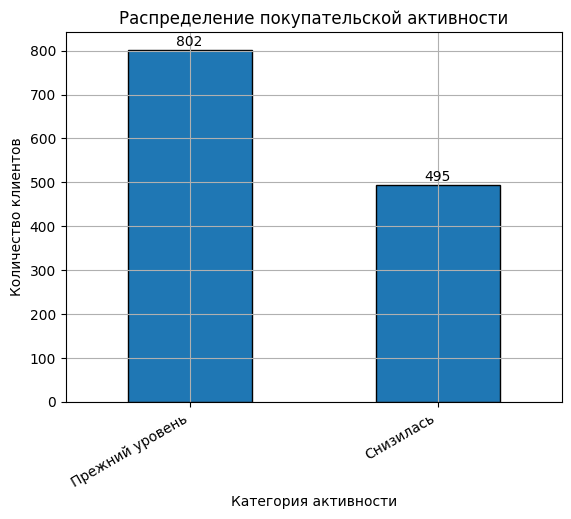

In [37]:
# напишем функцию для построения столбчатой диаграммы
def barplot_creation(data, column, title, ylabel, xlabel):
    column_value_counts = data[column].value_counts()
    column_value_counts.plot(kind='bar', edgecolor='black')
    for i, value in enumerate(column_value_counts):
        plt.text(i, value+1, str(value), ha='center', va='bottom', fontsize=10)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.xticks(rotation=30, ha='right')
    plt.grid(True)
    return plt.show()

# вызовем функцию
barplot_creation(market_file_3_month, 'покупательская_активность', 'Распределение покупательской активности', 'Количество клиентов', 'Категория активности')

* Согласно диаграмме, покупательская активность большинства покупателей остаётся на прежнем уровне  — **802** клиента.
* Покупательская активность снизилась у **495** клиентов.

* Построим столбчатую диаграмму для анализа распределения признаков в столбце `тип_сервиса`:

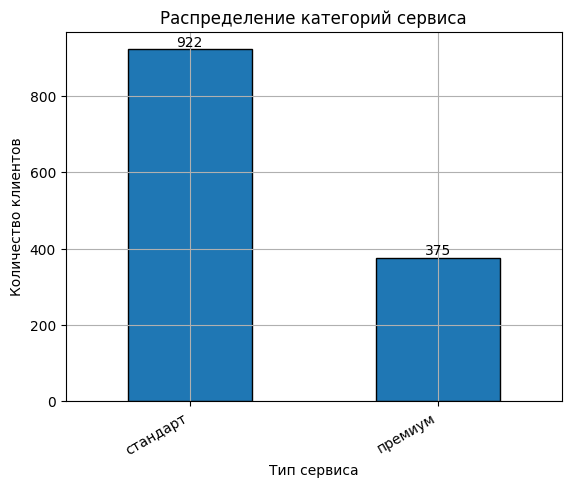

In [38]:
# вызовем функцию для построения столбчатой диаграммы 
barplot_creation(market_file_3_month, 'тип_сервиса', 'Распределение категорий сервиса', 'Количество клиентов', 'Тип сервиса')

* Большинство клиентов пользуются стандартным типом сервиса — **922**.
* Количество премиум-клиентов  — **375**.
* Возможно, клиенты чаще предпочитают стандартный тип сервиса, так как стандартный и премиальный типы не имеют сильных различий и стандартный функционал покрывает базовые потребности покупателей. Также можно предположить, что премиальных клиентов меньше по причине маркетинговой стратегии  — слабой презентации преимуществ платных опций.

* Построим столбчатую диаграмму для анализа распределения категориальных бинарных признаков в столбце `разрешить_сообщать`:

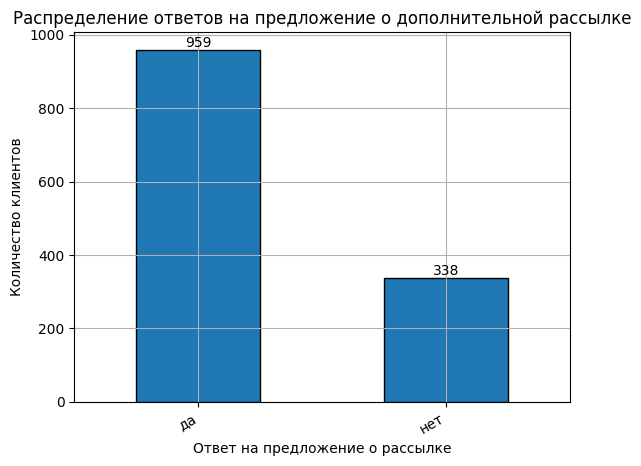

In [39]:
# вызовем функцию и построим столбчатую диаграмму 
barplot_creation(market_file_3_month, 'разрешить_сообщать', 'Распределение ответов на предложение о дополнительной рассылке', 'Количество клиентов', 'Ответ на предложение о рассылке')

* Большинство клиентов согласны получать дополнительные предложения о товаре — **959** клиентов.
* **26%** клиентов от общего числа целевых покупателей не дают сервису разрешение на рассылку дополнительных предложений о товаре — **338** клиентов.
* Такое соотношение может объясняться особенностями поведения пользователей на этапе оформления заказа. В частности, высокая доля согласий может быть связана с тем, что клиенты автоматически соглашаются с рассылкой, не задумываясь. Если форма оформления уже содержит галочку "да" или формулировка звучит обтекаемо, большинство пользователей нажимает на галочку, так как стремится как можно быстрее завершить покупку.

* Построим гистограмму для анализа распределения непрерывных количественных признаков в столбце с среднемесячным значением маркетинговых коммуникаций компании  — `маркет_актив_6_мес`:

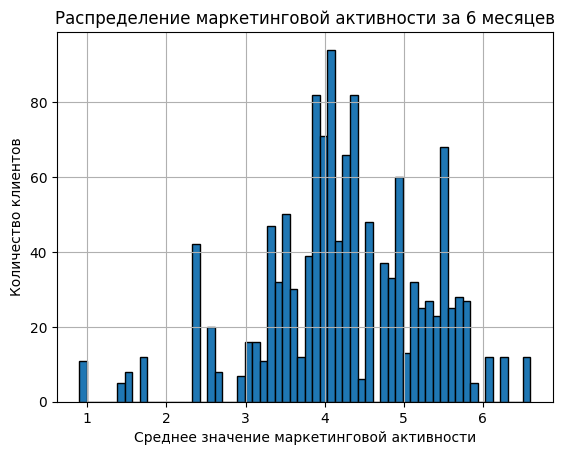

In [40]:
# напишем функцию для построения гистограммы
def hist_creation(data, column, bins, title, ylabel, xlabel):
    data[column].hist(bins=bins, edgecolor='black')
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.grid(True)
    return plt.show()

# вызовем функцию
hist_creation(market_file_3_month, 'маркет_актив_6_мес', 60, 'Распределение маркетинговой активности за 6 месяцев', 'Количество клиентов', 'Среднее значение маркетинговой активности')

* Гистограмма показывает нормальное распределение с небольшой асимметрией влево.
* Можно заметить отдельные небольшие значения приблизительно у отметок **1** и **1.5**, а также отдельные крупные значения у отметок **6** и **6.5**.

Ознакомимся с числовым описанием столбца:

In [41]:
# выведем числовые характеристики
market_file_3_month['маркет_актив_6_мес'].describe()

count    1297.000000
mean        4.254433
std         1.015618
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
Name: маркет_актив_6_мес, dtype: float64

* Не особенно высокое стандартное отклонение  — **1**.
* Среднее и медианное значения практически равны — **4.25** и **4.20**.

Проверим данные на выбросы, построим диаграмму размаха:

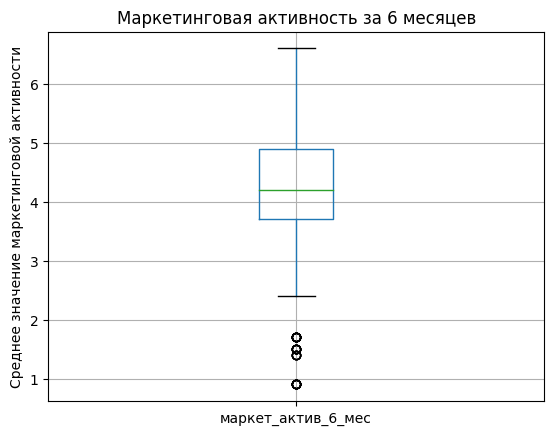

In [42]:
# напишем функцию для построения диаграммы размаха
def boxplot_creation(data, column, title, ylabel):
    data.boxplot(column=column)
    plt.title(title)
    plt.ylabel(ylabel)
    return plt.show()

# вызовем функцию
boxplot_creation(market_file_3_month, 'маркет_актив_6_мес', 'Маркетинговая активность за 6 месяцев', 'Среднее значение маркетинговой активности')

* Диаграмма размаха показывает выбросы у нижнего "уса", приблизительно в диапазоне от **1** до **2**.

Для исследования был предоставлен маленький объём данных. Мы не будем удалять выбросы, так как нам важно учесть всю информацию о целевых клиентах.

* Проанализируем распределение количества маркетинговых коммуникаций в текущем месяце в столбце `маркет_актив_тек_мес`. Построим столбчатую диаграмму для анализа дискретных количественных признаков:

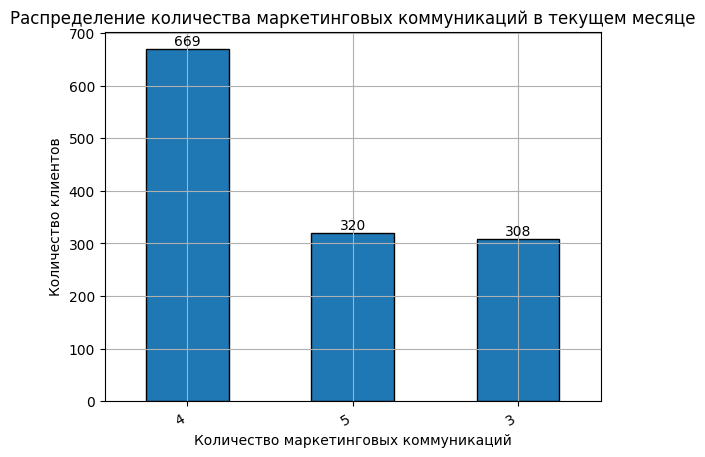

In [43]:
# вызовем функцию для построения столбчатой диаграммы
barplot_creation(market_file_3_month, 'маркет_актив_тек_мес', 'Распределение количества маркетинговых коммуникаций в текущем месяце', 'Количество клиентов', 'Количество маркетинговых коммуникаций')

* Чаще всего на клиента приходится 4 маркетинговых контакта — **669** клиентов.
* На приблизительно одинаковое количество покупателей приходится по **3** и **5** маркетинговых контактов  — **308** и **320** клиентов.

* Проанализируем распределение количества дней, прошедших с момента регистрации покупателя на сайте. Построим гистограмму по столбцу `длительность`:

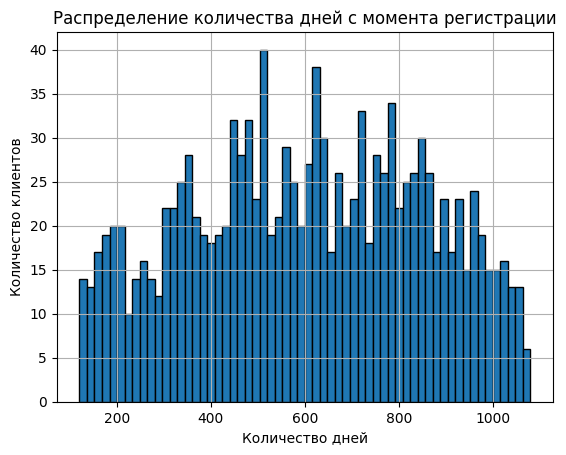

In [44]:
# вызовем функцию для построения гистограммы
hist_creation(market_file_3_month, 'длительность', 60, 'Распределение количества дней с момента регистрации', 'Количество клиентов', 'Количество дней')

* Гистограмма показывает равномерное распределение значений в столбце. 
* Отсутствуют отдельные необычно крупные или маленькие значения.

Ознакомимся с числовым описанием столбца:

In [45]:
# выведем числовое описание с помощью describe()
market_file_3_month['длительность'].describe()

count    1297.000000
mean      602.993832
std       249.101456
min       121.000000
25%       410.000000
50%       607.000000
75%       806.000000
max      1079.000000
Name: длительность, dtype: float64

* Достаточно высокое стандартное отклонение — **249.1**.
* Медианное и среднее значения практически равны  — **607** и **602.9**.
* Минимальное и максимальное значения выглядят реалистично  — **121** и **1079** дней. Постоянные клиенты действительно могут пользоваться интернет-магазином продолжительное время из-за удобного функционала.

Проверим столбец на наличие выбросов, построим диаграмму размаха:

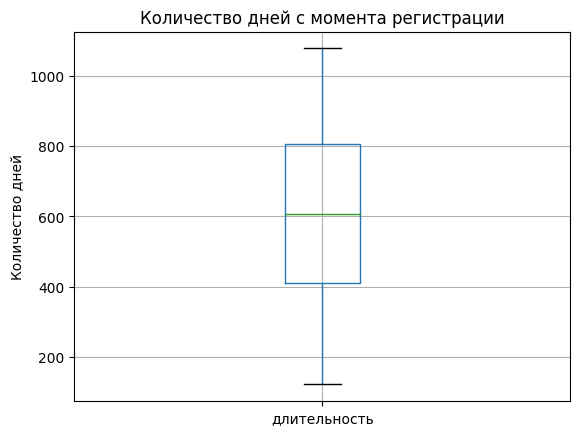

In [46]:
# вызовем функцию для построения диаграммы размаха
boxplot_creation(market_file_3_month, 'длительность', 'Количество дней с момента регистрации', 'Количество дней')

* "Ящик с усами" показывает отсутствие выбросов в столбце.

* Проанализируем распределение среднемесячной доли покупок по акции от общего числа покупок за последние 6 месяцев. Построим гистограмму по столбцу `акционные_покупки`:

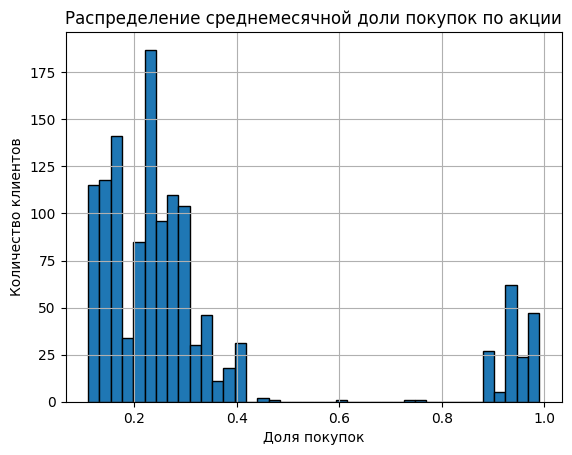

In [47]:
# вызовем функцию для построения гистограммы
hist_creation(market_file_3_month, 'акционные_покупки', 40, 'Распределение среднемесячной доли покупок по акции', 'Количество клиентов', 'Доля покупок')

* Гистограмма показывает распределение с изолированным пиком: видна концентрация значений в диапазоне от **0.9** до **1.0**.
* Большинство значений сконцентрировано в диапазоне приблизительно от **0.1** до **0.4**. Количество покупателей растёт примерно до **190** у отметки **0.2** и снижается до **30** у отметки **0.4**.
* Можно заметить тонкий хвост, который тянется от отметки **0.4** до **0.8**. Возможно, такие редкие значения являются выбросами.

Проверим данные на выбросы. Построим диаграмму размаха:

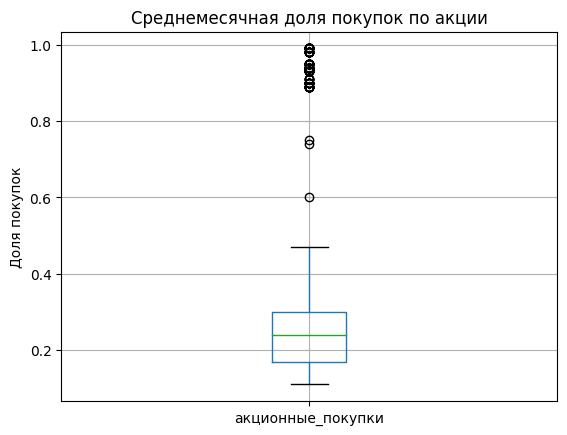

In [48]:
# вызовем функцию для построения диаграммы размаха
boxplot_creation(market_file_3_month, 'акционные_покупки', 'Среднемесячная доля покупок по акции', 'Доля покупок') 

* Диаграмма размаха показывает выбросы приблизительно у отметок **0.6**, **0.7**, а также от **0.9** до **1**.

Мы не будет фильтровать выбросы по причине маленького объёма данных.

* Проанализируем категориальные переменные в столбце `популярная_категория`. Построим столбчатую диаграмму:

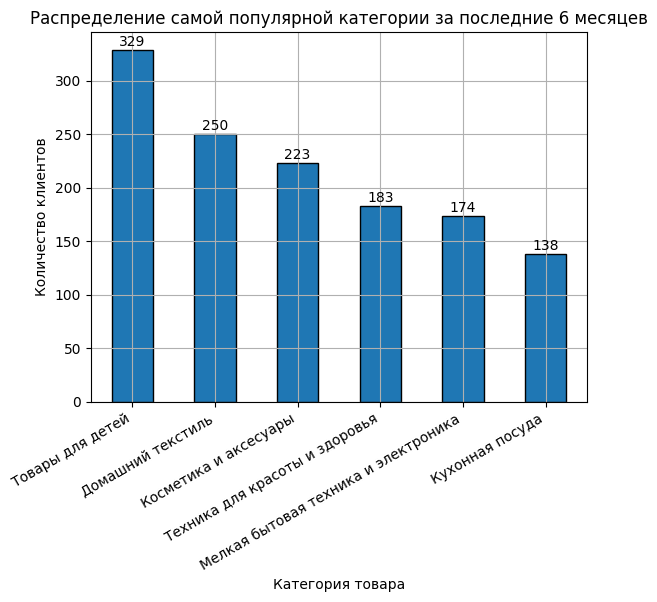

In [49]:
# вызовем функцию для построения столбчатой диаграммы
barplot_creation(market_file_3_month, 'популярная_категория', 'Распределение самой популярной категории за последние 6 месяцев', 'Количество клиентов', 'Категория товара')

* Самая популярная категория товаров за последние 6 меясцев — `товары для детей`. **329** активных клиентов совершает покупки товаров в этой категории.
* `Кухонная посуда` пользуется среди покупателей наименьшим спросом - всего **138** клиентов.
* Такое распределение значений можно объяснить тем, что `детские товары` имеют естественно повторяющийся спрос — ребёнок растёт, предыдущий размер «сгорает», и родители вынуждены докупать следующий. `Кухонная посуда` такой потребности не создаёт и может служить достаточно продолжительный срок.

* Проанализируем столбец `средний_просмотр_категорий_за_визит`, который показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца. Оценим распределение с помощью столбчатой диаграммы, так как в столбце находятся дискретные числовые переменные в небольшом диапазоне:

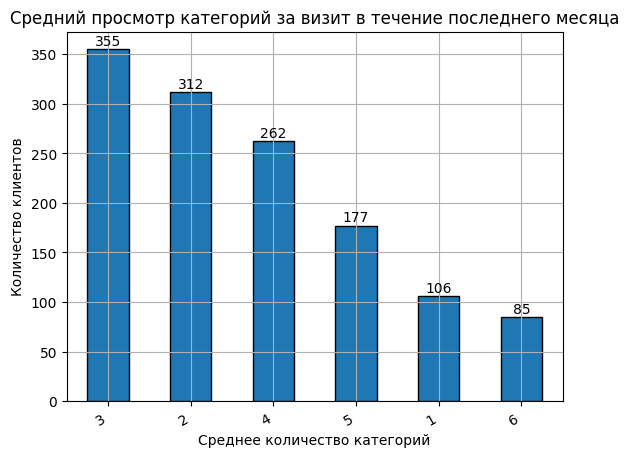

In [50]:
# вызовем функцию для построения столбчатой диаграммы
barplot_creation(market_file_3_month, 'средний_просмотр_категорий_за_визит', 'Средний просмотр категорий за визит в течение последнего месяца', 'Количество клиентов', 'Среднее количество категорий')

* В среднем в течение последнего месяца самое большое число клиентов просмотрело **3** категории товаров за визит — **355** клиентов. 
* Немного меньше клиентов просмотрело **2** категории товаров за визит  — **312**.
* Всего лишь **85** клиентов просмотрело в среднем **6** категорий за один визит.

* Проанализируем распределение значений в столбце `неоплаченные_продукты_штук_квартал` c общим числом неоплаченных товаров в корзине за последние 3 месяца:

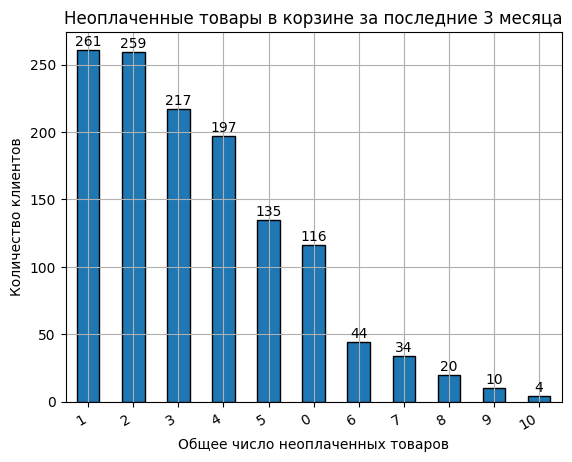

In [51]:
# вызовем функцию для построения столбчатой диаграммы
barplot_creation(market_file_3_month, 'неоплаченные_продукты_штук_квартал', 'Неоплаченные товары в корзине за последние 3 месяца', 'Количество клиентов', 'Общее число неоплаченных товаров')

* Чаще всего у покупателей в корзине находится по **1** или **2** неоплаченным товарам за последние **3** месяца, гораздо реже — **9** или **10** товаров.

Проверим столбец на наличие выбросов с помощью диаграммы размаха:

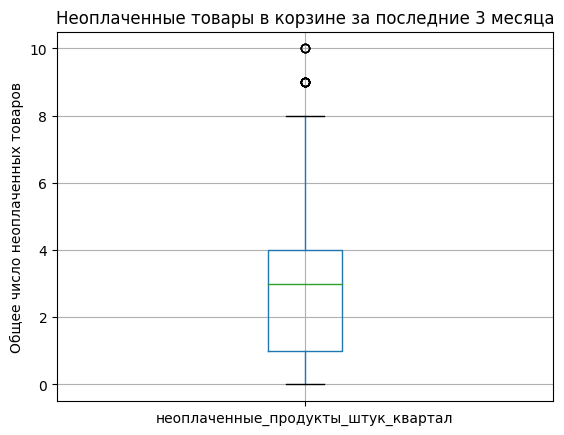

In [52]:
# вызовем функцию для построения диаграммы размаха
boxplot_creation(market_file_3_month, 'неоплаченные_продукты_штук_квартал', 'Неоплаченные товары в корзине за последние 3 месяца', 'Общее число неоплаченных товаров')

* "Ящик с усами" показывает выбросы у отметок **9** и **10**.

Мы не будем удалять строки с выбросами по причине маленького объёма данных о целевых клиентах.

* Проанализируем распределение значений в столбце `ошибка_сервиса` c числом сбоев, которые коснулись покупателя во время посещения сайта:

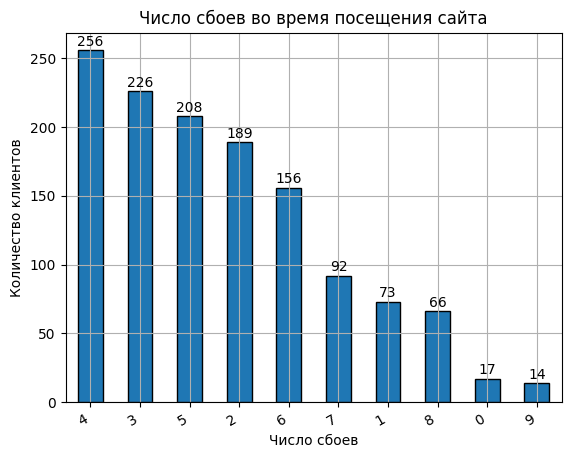

In [53]:
# вызовем функцию для построения столбчатой диаграммы
barplot_creation(market_file_3_month, 'ошибка_сервиса', 'Число сбоев во время посещения сайта', 'Количество клиентов', 'Число сбоев')

* Чаще всего покупатели сталкиваются с **3-4** ошибками сервиса во время посещения сайта — **226** и **256** клиентов. 
* Реже всего покупатели сталкиваются с **9** ошибками или ошибки отсутствуют во время посещения — **14** и **17** клиентов. 

Проверим данные на наличие выбросов:

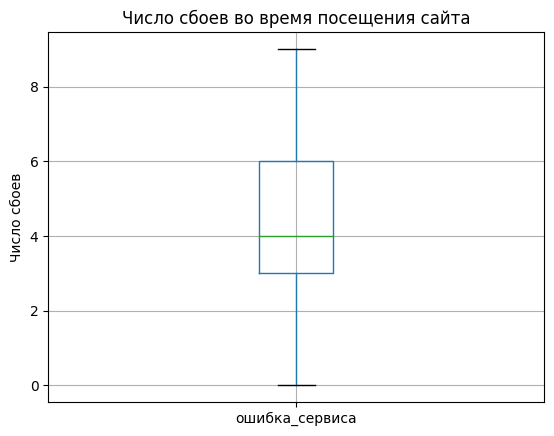

In [54]:
# вызовем функцию для построения диаграммы размаха
boxplot_creation(market_file_3_month, 'ошибка_сервиса', 'Число сбоев во время посещения сайта', 'Число сбоев')

* Диаграмма показывает отсутствие выбросов.

 * Проанализируем столбец `страниц_за_визит` со средним количеством страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца:

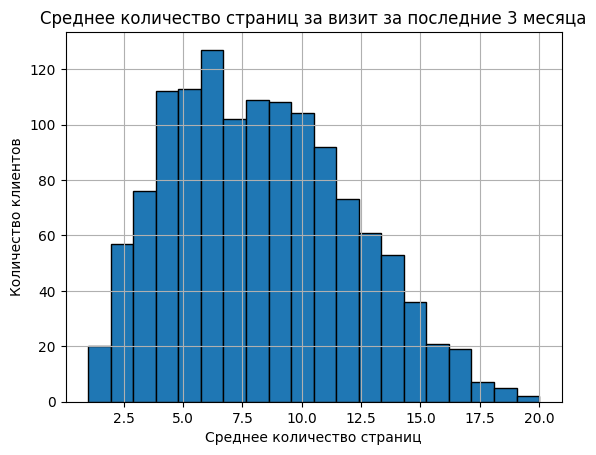

In [55]:
# вызовем функцию для построения столбчатой диаграммы
hist_creation(market_file_3_month, 'страниц_за_визит', 20, 'Среднее количество страниц за визит за последние 3 месяца', 'Количество клиентов', 'Среднее количество страниц')

* Гистограмма показывает нормальное распределение значений в столбце с небольшой асимметрией вправо.

Ознакомимся с числовым описанием данных:

In [56]:
# выведем числовое описание с помощью describe()
market_file_3_month['страниц_за_визит'].describe()

count    1297.000000
mean        8.186584
std         3.977061
min         1.000000
25%         5.000000
50%         8.000000
75%        11.000000
max        20.000000
Name: страниц_за_визит, dtype: float64

* Медианное и среднее значение практически равны — **8** и **8.1**.
* Минимальное и максимальное значения выглядят реалистично — **1** и **20**.

Проверим столбец на выбросы, построим диаграмму размаха:

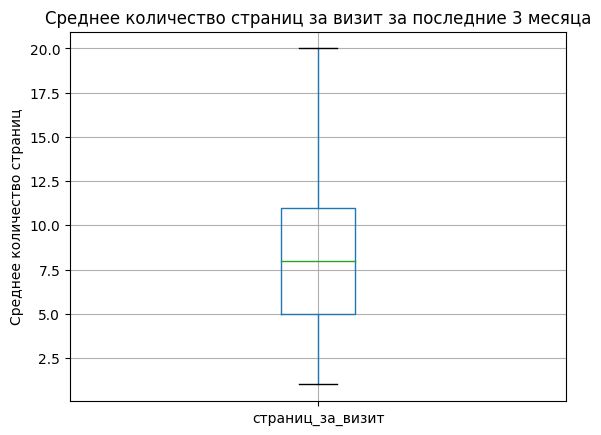

In [57]:
# вызовем функцию для построения диаграммы размаха
boxplot_creation(market_file_3_month,'страниц_за_визит', 'Среднее количество страниц за визит за последние 3 месяца', 'Среднее количество страниц')

* Диаграмма размаха показывает отсутствие выбросов в столбце.

<a name="3.2"></a>
### Статистический анализ данных в market_money

Отберём клиентов с покупательской активностью не менее трёх месяцев:

In [58]:
# отфильтруем целевых клиентов и сохраним в переменную 
market_money_3_month = market_money[market_money['id'].isin(clients_activity_id)]

# проверим результат
market_money_3_month.head(20)

,id,период,выручка
3,215349,предпредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6
5,215349,предыдущий_месяц,5216.0
6,215350,предпредыдущий_месяц,4826.0
7,215350,текущий_месяц,5058.4
8,215350,предыдущий_месяц,5457.5
9,215351,текущий_месяц,6610.4
10,215351,предыдущий_месяц,6158.0
11,215351,предпредыдущий_месяц,4793.0
12,215352,предыдущий_месяц,5807.5


In [59]:
# проверим размерность отфильтрованного датафрейма
market_money_3_month.shape

(3891, 3)

В отфильтрованной таблице с целевыми клиентами получилось **3891** строк, так как каждому клиенту с уникальным `id` соответствует **3** строки с **3** разными периодами: `текущий_месяц`, `предыдущий_месяц` и `предпредыдущий_месяц`.

* Чтобы убедиться в этом, построим столбчатую диаграмму по столбцу `период`:

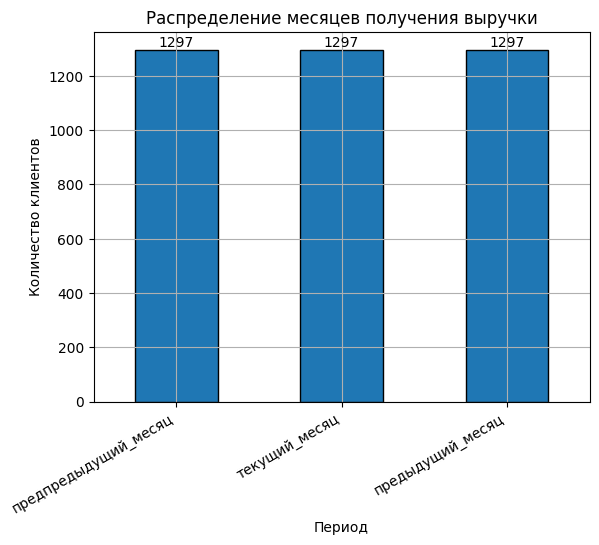

In [60]:
# вызовем функцию для построения столбчатой диаграммы
barplot_creation(market_money_3_month, 'период', 'Распределение месяцев получения выручки', 'Количество клиентов', 'Период')

* В каждой категории находится равное количество клиентов — **1297**.

* Проанализируем распределение количественных непрерывных переменных в столбце `выручка`:

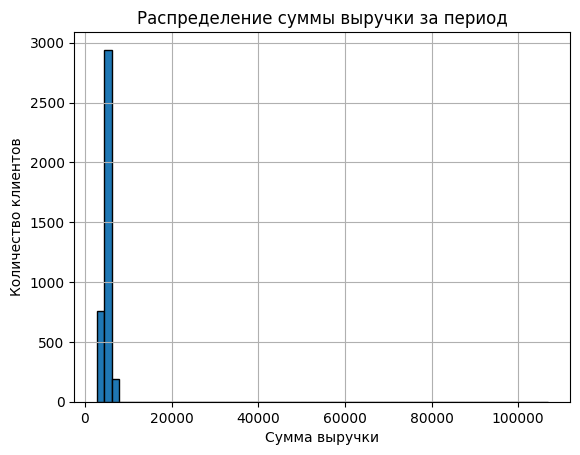

In [61]:
# вызовем функцию для построения гистограммы
hist_creation(market_money_3_month, 'выручка', 60, 'Распределение суммы выручки за период', 'Количество клиентов', 'Сумма выручки')

* На гистограмме виден высокий узкий пик приблизительно у отметки в **5 000** рублей. Большинство значений сконцентрировано в диапазоне примерно от **2 000** до **7 000** рублей.
* Ось x растянута до **100 000** и далее. Можно предположить, что есть редкие, но аномально крупные суммы. Возможно, их мало и поэтому незаметно визуально на текущем масштабе гистограммы.

Ознакомимся с числовым описанием столбца:

In [62]:
# выведем числовое описание с помощью describe()
market_money_3_month['выручка'].describe()

count      3891.000000
mean       5033.718890
std        1768.471286
min        2758.700000
25%        4592.000000
50%        4959.000000
75%        5363.200000
max      106862.200000
Name: выручка, dtype: float64

* Среднее арифметическое — **5 033.7** немного выше медианы **4959**.
* Минимальное значение — **2 758.7** выглядит реалистично. 
* Максимальное значение — **106 862.2** вызывает сомнения. Такая выручка за один месяц может говорить о крупной разовой оптовой B2B-закупке. Обычно физические лица совершают покупки меньшего масштаба в интернет-магазине. 

Проверим данные на наличие выбросов:

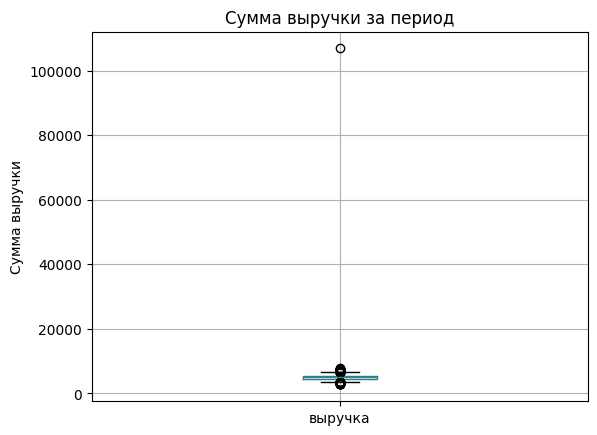

In [63]:
# вызовем функцию для построения диаграммы размаха
boxplot_creation(market_money_3_month, 'выручка', 'Cумма выручки за период', 'Сумма выручки')

* Диаграмма размаха подтверждает наличие выбросов в столбце. Видна концентрация редких значений приблизительно у отметок **10 000**, **2 000**, а также максимальное значение — **106 862.2**.

Проверим `id` покупателя и `период` полученной выручки в размере **106862.2**:

In [64]:
# отфильтруем строки с помощью query()
market_money_3_month.query('выручка == 106862.2')

,id,период,выручка
98,215380,текущий_месяц,106862.2


Ознакомимся с чеками клиента с `id` **215380** за другие периоды:

In [65]:
# отфильтруем строки с помощью query()
market_money_3_month.query('id == 215380')

,id,период,выручка
96,215380,предпредыдущий_месяц,5051.0
97,215380,предыдущий_месяц,6077.0
98,215380,текущий_месяц,106862.2


* Выручка за `текущий_месяц` действительно сильно отличается от чеков за `предыдущий` и `предпредыдущий` месяцы. 

Несмотря на маленький объём данных в целом, значения больше 100 000 — очевидный выброс, который следует удалить из таблицы. Так модель будет искать общие закономерности в данных, а не подстраиваться под аномально высокие значения.

Отфильтруем данные в столбце, удалим значения выше 100 000:

In [66]:
# отфильтруем данные в столбце с помощью query()
market_money_3_month = market_money_3_month.query('выручка < 100_000')

# проверим результат, выведем 10 строк
# отсортируем строки по убыванию
market_money_3_month['выручка'].head(10).sort_values(ascending=False)

9     6610.4
10    6158.0
12    5807.5
8     5457.5
5     5216.0
7     5058.4
4     4971.6
6     4826.0
11    4793.0
3     4472.0
Name: выручка, dtype: float64

<a name="3.3"></a>
### Статистический анализ данных в market_time

Отфильтруем клиентов с покупательской активностью не менее трёх месяцев:

In [67]:
# отфильтруем активных клиентов с помощью isin() 
market_time_3_month = market_time[market_time['id'].isin(clients_activity_id)]

# проверим результат, выведем 30 первых строк
market_time_3_month.head(30)

,id,период,минут
2,215349,текущий_месяц,10
3,215349,предыдущий_месяц,12
4,215350,текущий_месяц,13
5,215350,предыдущий_месяц,8
6,215351,текущий_месяц,13
7,215351,предыдущий_месяц,11
8,215352,текущий_месяц,11
9,215352,предыдущий_месяц,8
10,215353,предыдущий_месяц,10
11,215353,текущий_месяц,10


In [68]:
# проверим размерность получившегося датафрейма
market_time_3_month.shape

(2594, 3)

В таблице получилось **2594** строки, так как каждому клиенту с уникальным `id` соответствует **2** периода: `текущий_месяц` и `предыдущий_месяц`. Убедимся в этом, построим столбчатую диаграмму по столбцу `период`:

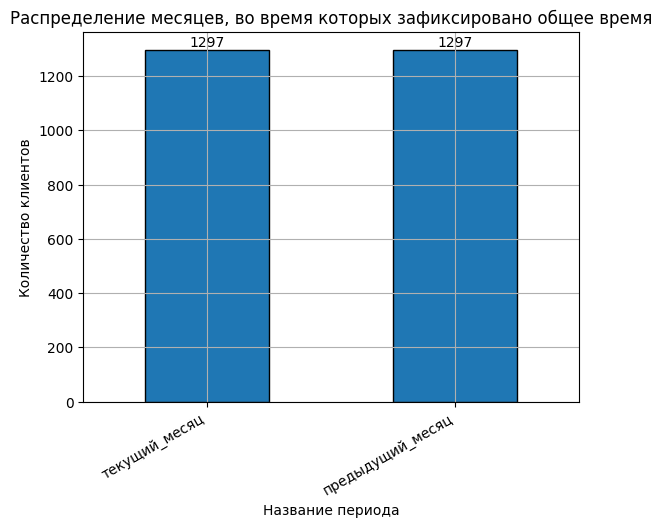

In [69]:
# вызовем функцию для построения столбчатой диаграммы
barplot_creation(market_time_3_month, 'период', 'Распределение месяцев, во время которых зафиксировано общее время', 'Количество клиентов', 'Название периода')

* В двух столбцах содержится одинаковое количество клиентов — **1297**.

* Проанализируем распределение дискретных количественных переменных в столбце `минут`:

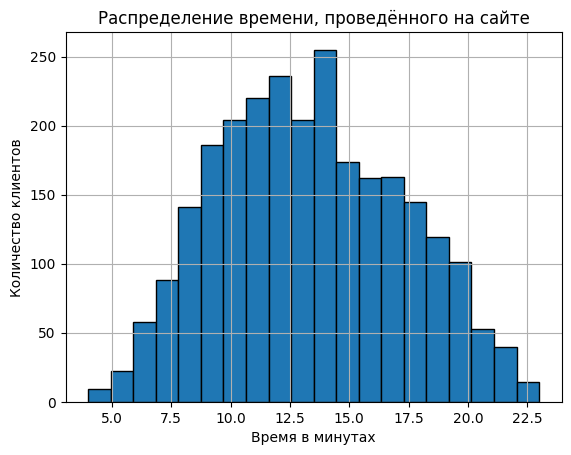

In [70]:
# вызовем функцию для построения гистограммы
hist_creation(market_time_3_month, 'минут', 20, 'Распределение времени, проведённого на сайте', 'Количество клиентов', 'Время в минутах')

* Гистограмма показывает нормальное распределение значений в столбце.
* Отсутствуют "хвосты" или отдельные, слишком крупные или мелкие значения.

Ознакомимся с числовыми характеристиками столбца:

In [71]:
# выведем числовое описание 
market_time_3_month['минут'].describe()

count    2594.000000
mean       13.340401
std         4.081999
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: минут, dtype: float64

* Среднее — **13.3** незначительно больше медианы — **13**.
* Минимальное и максимальное значения вполне реалистичны — **4** и **23** минуты.

Проверим данные на выбросы, построим диаграмму размаха:

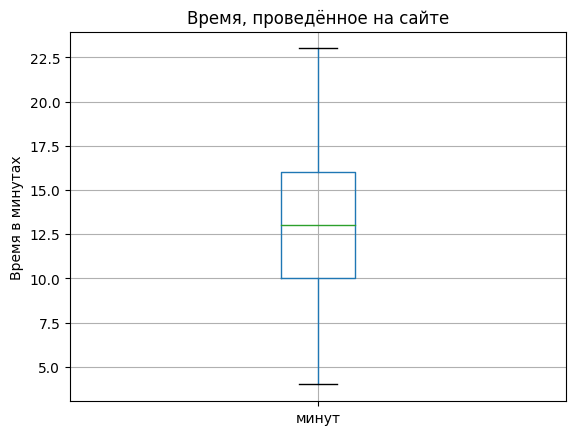

In [72]:
# вызовем функцию для построения диаграммы размаха
boxplot_creation(market_time_3_month, 'минут', 'Время, проведённое на сайте', 'Время в минутах')

* Диаграмма размаха показывает отсутствие выбросов в столбце.

<a name="3.4"></a>
### Статистический анализ данных в money

Отфильтруем активных клиентов, которые совершали покупки в течение всех 3 месяцев:

In [73]:
# отфильтруем активных клиентов с помощью isin()
money_3_month = money[money['id'].isin(clients_activity_id)]

# проверим результат, выведем первые 10 строк
money_3_month.head(10)

,id,прибыль
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21
5,215353,3.95
6,215354,3.62
7,215355,5.26
8,215356,4.93
10,215358,3.06
12,215360,4.55


In [74]:
# выведем размерность получившегося датафрейма
money_3_month.shape

(1297, 2)

Можно предположить, что значения в столбце `прибыль` это агрегированный показатель в тысячах рублей или в % к обороту.

* Проанализируем распределение непрерывных количественных переменных в столбце `прибыль` со среднемесячной прибылью продавца за последние 3 месяца:

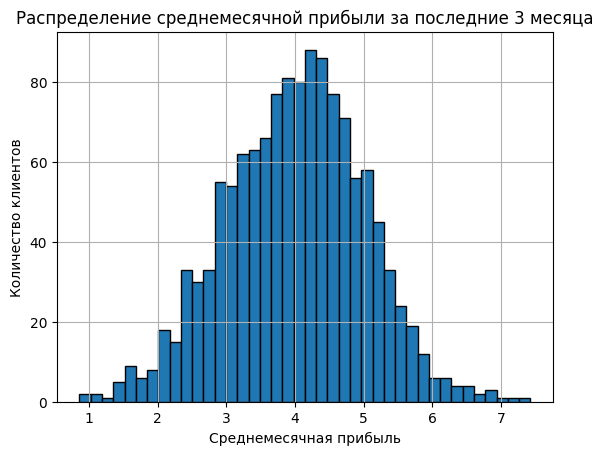

In [75]:
# вызовем функцию для построения гистограммы
hist_creation(money_3_month, 'прибыль', 40, 'Распределение среднемесячной прибыли за последние 3 месяца', 'Количество клиентов', 'Среднемесячная прибыль')

* Гистограмма показывает нормальное распределение значений в столбце.
* Заметны тонкие хвосты по левому и правому краю распределения: приблизительно от отметки **0.5** до **1.5** и от **7** до **7.5**. Возможно, в данных есть выбросы, слишком мелкие или крупные значения.

Ознакомимся с числовым описанием данных:

In [76]:
# выведем числовое описание с помощью describe()
money_3_month['прибыль'].describe()

count    1297.000000
mean        3.997610
std         1.010813
min         0.860000
25%         3.300000
50%         4.040000
75%         4.670000
max         7.430000
Name: прибыль, dtype: float64

* Медианное и среднее значения практически одинаковы — **4.04** и **3.99**.

Проверим данные на выбросы, построим диаграмму размаха:

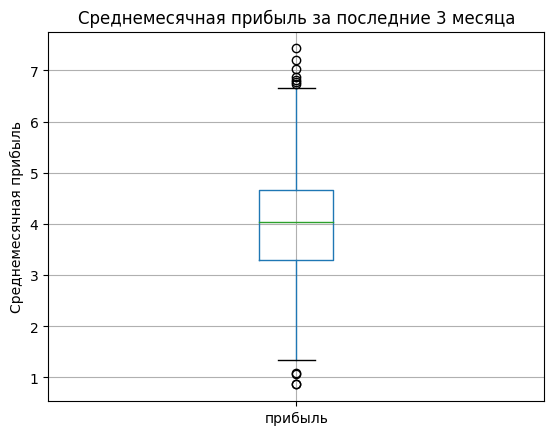

In [77]:
# вызовем функцию для построения диаграммы размаха
boxplot_creation(money_3_month, 'прибыль', 'Cреднемесячная прибыль за последние 3 месяца', 'Среднемесячная прибыль')

* Диаграмма показывает выбросы приблизительно у отметок **1**, а также от **6.5** до **7.8**.

**Выводы:**

* Мы отфильтровали активных клиентов во всех 4 таблицах.
* Обнаружили выбросы в отфлильтрованных таблицах **market_file_3_month** (в столбцах: `маркет_актив_6_мес`, `акционные_покупки`, `неоплаченные_продукты_штук_квартал`), в **market_money_3_month** (`выручка`), в **money_3_month** (`прибыль`).
* Мы не отфильтровали строки с выбросами, так как в таблицах представлен небольшой объём данных о целевых клиентах. Удаление выбросов может привести к некорректному обучению моделей в дальнейшем.

<a name="3.5"></a>
### Объединение таблиц

Объединим отфильтрованные таблицы `market_file_3_month`, `market_money_3_month`, `market_time_3_month`. Данные о прибыли в `money_3_month` не понадобятся нам при моделировании.

Перед объединением ещё раз выведем размерность датафреймов:

In [78]:
# выведем размерность датафрейма market_file_3_month
market_file_3_month.shape

(1297, 13)

In [79]:
# выведем размерность датафрейма market_money_3_month
market_money_3_month.shape

(3890, 3)

In [80]:
# выведем размерность датафрейма market_time_3_month
market_time_3_month.shape

(2594, 3)

Объединим таблицы:

In [81]:
# объединим таблицы с помощью merge()
file_money_time_3_month = (
    market_money_3_month
    .merge(market_time_3_month, on=['id', 'период'], how='outer')
    .merge(market_file_3_month, on='id', how='outer')
)

# выведем размерность получившегося датафрейма
file_money_time_3_month.shape

(3891, 16)

In [82]:
# проверим результат, выведем первые 20 строк
file_money_time_3_month.head(20)

,id,период,выручка,минут,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
0,215349,предпредыдущий_месяц,4472.0,NaN,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
1,215349,предыдущий_месяц,5216.0,12.0,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215349,текущий_месяц,4971.6,10.0,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
3,215350,предпредыдущий_месяц,4826.0,NaN,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
4,215350,предыдущий_месяц,5457.5,8.0,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
5,215350,текущий_месяц,5058.4,13.0,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
6,215351,предпредыдущий_месяц,4793.0,NaN,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
7,215351,предыдущий_месяц,6158.0,11.0,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
8,215351,текущий_месяц,6610.4,13.0,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
9,215352,предпредыдущий_месяц,4594.0,NaN,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


Учтём, что данные о выручке и времени на сайте находятся в одном столбце для всех периодов. В итоговой таблице сделаем отдельный столбец для каждого периода:

In [83]:
# cоздадим сводную таблицу с отдельными столбцами для каждого периода
file_money_time_pivot = (
    file_money_time_3_month
    .pivot_table(index='id', columns='период', values=['выручка','минут'])
)

# уберём мультииндекс, склеим названия столбцов с помощью map() и join
file_money_time_pivot.columns = file_money_time_pivot.columns.map('_'.join)

# проверим результат
file_money_time_pivot.head()

,выручка_предпредыдущий_месяц,выручка_предыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
id,,,,,
215349,4472.0,5216.0,4971.6,12.0,10.0
215350,4826.0,5457.5,5058.4,8.0,13.0
215351,4793.0,6158.0,6610.4,11.0,13.0
215352,4594.0,5807.5,5872.5,8.0,11.0
215353,5124.0,4738.5,5388.5,10.0,10.0


In [84]:
# объединим file_money_time_3_month и сводную таблицу с помощью merge()
# уберём строки-дубликаты
# уберём старый индекс и добавим новый
file_money_time_3_month = (
    file_money_time_3_month
    .drop(columns=['период','выручка','минут'])
    .merge(file_money_time_pivot, on='id', how='outer')
    .drop_duplicates(subset='id')
    .reset_index(drop=True)
)

# проверим результат, выведем 5 первых строк
file_money_time_3_month.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предпредыдущий_месяц,выручка_предыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12.0,10.0
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8.0,13.0
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11.0,13.0
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8.0,11.0
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10.0,10.0


In [85]:
# проверим размерность получившегося датафрейма
file_money_time_3_month.shape

(1297, 18)

<a name="4"></a>
## Корреляционный анализ признаков 

Проведём корреляционный анализ признаков в количественной шкале в итоговой таблице для моделирования. 

Рассчитаем коэффициент корреляции Спирмена, так как в некоторых столбцах датафрейма встречается ненормальное, асимметричное распределение значений:

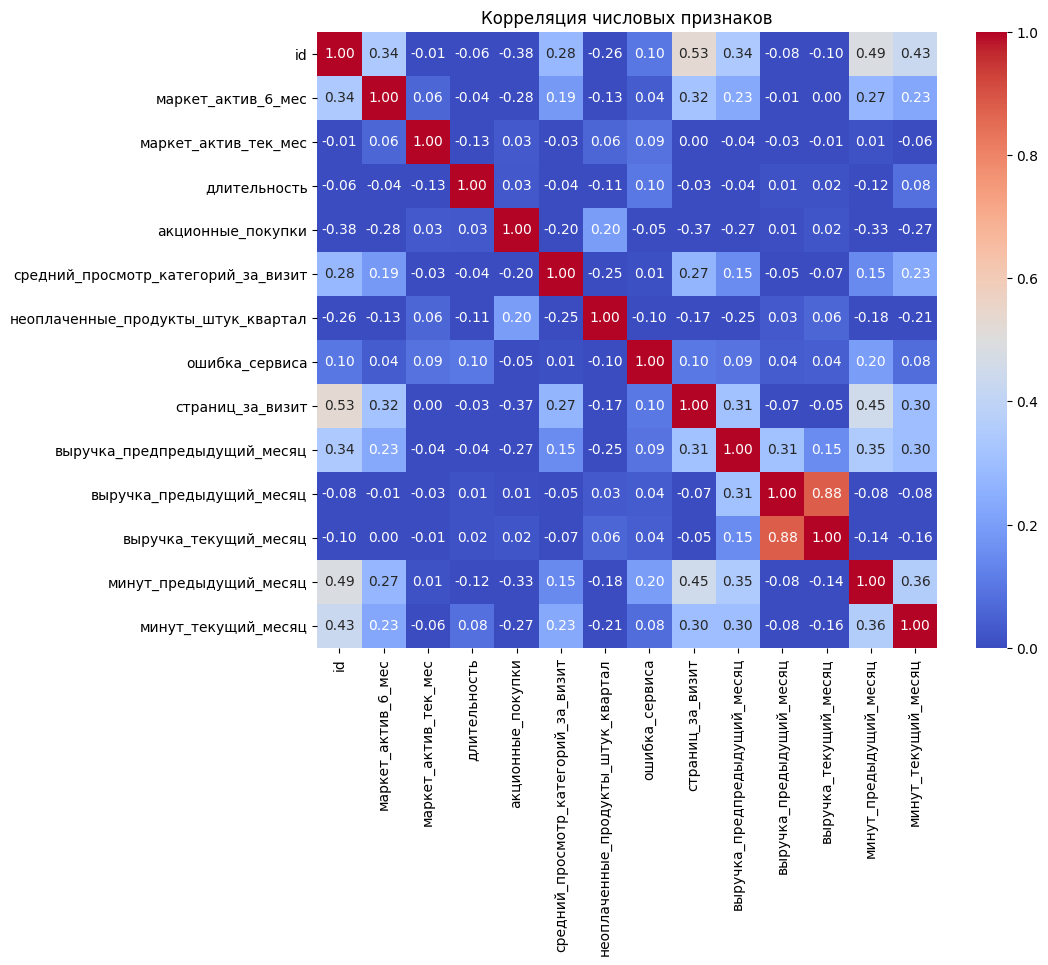

In [86]:
# рассчитаем коэффициент корреляции Спирмена для всех числовых признаков
corr_spearman_3_month = file_money_time_3_month.select_dtypes(include='number').corr(method='spearman')

# визуализируем результат с помощью heatmap()
plt.figure(figsize=(10,8))
sns.heatmap(corr_spearman_3_month, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1)
plt.title('Корреляция числовых признаков')
plt.show()

* В данных наблюдается мультиколлинеарность между числовыми входными признаками `выручка_предыдущий_месяц` и `выручка_текущий_месяц` со значением коэффициента корреляции **0.88**.

Мультиколлинеарность может исказить прогноз модели логистической регрессии, поэтому исключим один из признаков из датафрейма:

In [87]:
# сохраним копию исходного датафрейма, который пригодится позже при сегментации клиентов
# удалим признак из столбца нового датафрейма для обучения модели
file_money_time_3_month_new = file_money_time_3_month.copy()
file_money_time_3_month_new = file_money_time_3_month_new.drop(columns='выручка_предыдущий_месяц')

# проверим результат
file_money_time_3_month_new.columns

Index(['id', 'покупательская_активность', 'тип_сервиса', 'разрешить_сообщать',
       'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
       'акционные_покупки', 'популярная_категория',
       'средний_просмотр_категорий_за_визит',
       'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса',
       'страниц_за_визит', 'выручка_предпредыдущий_месяц',
       'выручка_текущий_месяц', 'минут_предыдущий_месяц',
       'минут_текущий_месяц'],
      dtype='object')

Рассчитаем корреляцию всех входных признаков датафрейма: как числовых, так и категориальных.

interval columns not set, guessing: ['id', 'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность', 'акционные_покупки', 'средний_просмотр_категорий_за_визит', 'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 'страниц_за_визит', 'выручка_предпредыдущий_месяц', 'выручка_текущий_месяц', 'минут_предыдущий_месяц', 'минут_текущий_месяц']


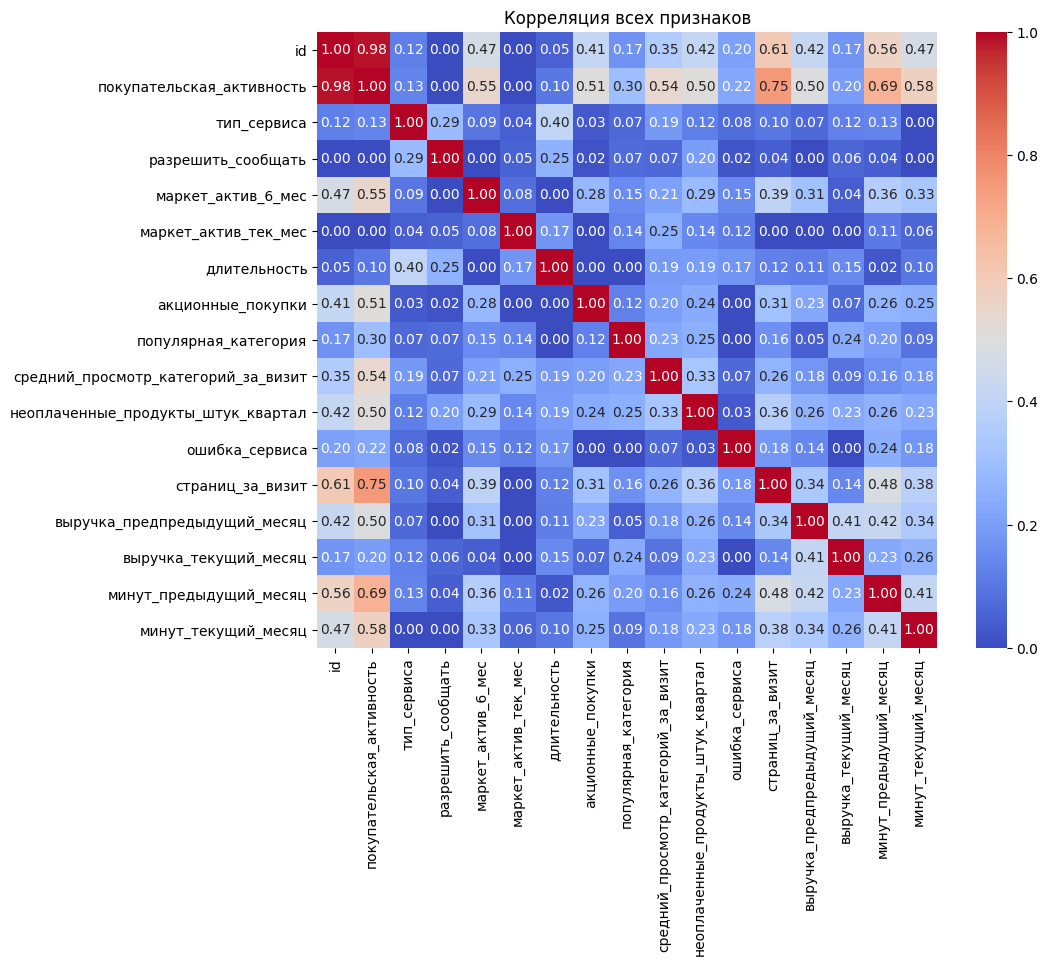

In [88]:
# используем phik_matrix() для расчёта корреляции всех признаков
# сохраним результат в переменной
phik_3_month = file_money_time_3_month_new.phik_matrix()

# визуализируем результат с помощью тепловой карты
plt.figure(figsize=(10,8))
sns.heatmap(phik_3_month, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1)
plt.title('Корреляция всех признаков')
plt.show()

* Между входными категориальными признаками отсутствует мультиколлинеарность.


* Целевой признак `покупательская активность` коррелирует с **категориальным** признаком `id` — **0.98**. Несмотря на высокую корреляцию, этот признак не должен участвовать в обучении моделей. `id` — это категориальный идентификатор, который не несёт смысловой нагрузки и не отражает поведение или характеристики клиента. Его высокая корреляция с целевой переменной, скорее всего, обусловлена утечкой данных. 


* Целевой признак имеет слабую корреляцию с категориальными переменными: `популярная_категория` — **0.30** и `тип_сервиса` — **0.13**.


* Целевой признак коррелирует со следующими **количественными** входными признаками: `маркет_актив_6_мес` — **0.55**, `акционные_покупки` — **0.51**, `средний_просмотр_категорий_за_визит` — **0.54**, `неоплаченные_продукты_штук_квартал` — **0.50**, `страниц_за_визит` — **0.75**, `выручка_предпредыдущий_месяц` — **0.50**, `минут_предыдущий_месяц` — **0.69**, `минут_текущий_месяц` — **0.58**. Более слабая корреляция у признаков `выручка_предыдущий_месяц`— **0.23**, `ошибка_сервиса` — **0.22**, `длительность` — **0.10**.

**Выводы**:

* Между числовыми входными признаками `выручка_предыдущий_месяц` и `выручка_текущий_месяц` обнаружили мультиколлинеарность — **0.88**. Удалили столбец `выручка_предыдущий_месяц` из таблицы.

* Целевой признак имеет слабую корреляцию с категориальными переменными: `популярная_категория` — **0.30** и `тип_сервиса` — **0.13**.
* Целевой признак `покупательская_активность` коррелирует с количественными входными признаками: `страниц_за_визит` — **0.75**, `минут_предыдущий_месяц` — **0.69**, `минут_текущий_месяц` — **0.58**, `маркет_актив_6_мес` — **0.55**, `средний_просмотр_категорий_за_визит` — **0.54**, `акционные_покупки` — **0.51**, `неоплаченные_продукты_штук_квартал` — **0.50**, `выручка_предпредыдущий_месяц` — **0.50**.
* Более слабая корреляция у числовых признаков `выручка_предыдущий_месяц`— **0.23**, `ошибка_сервиса` — **0.22**, `длительность` — **0.10**.

<a name="5"></a>
## Обучение прогнозных моделей

<a name="5.1"></a>
### Создание пайплайна

Применим модели `KNeighborsClassifier()`, `DecisionTreeClassifier()`, `LogisticRegression()` и `SVC()`. Для этого используем пайплайн.

Перечислим особенности данных:

In [89]:
# выведем первые 5 строк датафрейма
file_money_time_3_month_new.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предпредыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,4971.6,12.0,10.0
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5058.4,8.0,13.0
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6610.4,11.0,13.0
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5872.5,8.0,11.0
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,5388.5,10.0,10.0


In [90]:
# проверим данные на пропуски
file_money_time_3_month_new.isna().sum()

id                                     0
покупательская_активность              0
тип_сервиса                            0
разрешить_сообщать                     0
маркет_актив_6_мес                     0
маркет_актив_тек_мес                   0
длительность                           0
акционные_покупки                      0
популярная_категория                   0
средний_просмотр_категорий_за_визит    0
неоплаченные_продукты_штук_квартал     0
ошибка_сервиса                         0
страниц_за_визит                       0
выручка_предпредыдущий_месяц           0
выручка_текущий_месяц                  1
минут_предыдущий_месяц                 0
минут_текущий_месяц                    0
dtype: int64

Выведем строку с пропущенным значением:

In [91]:
# выведем строку с пропущенным значением с помощью isna() и any()
file_money_time_3_month_new[file_money_time_3_month_new.isna().any(axis=1)]

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предпредыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
29,215380,Снизилась,премиум,нет,1.7,4,637,0.94,Техника для красоты и здоровья,3,2,4,7,5051.0,NaN,12.0,14.0


1. Целевой признак — `покупательская_активность`. Модели будут решать задачу бинарной классификации, так как признак включает два класса `Прежний уровень` и `Снизилась`.


2. В столбце `выручка_текущий_месяц` присутствует 1 пропущенное значение, которое могло возникнуть после объединения таблиц. В пайплайне перед масштабированием заполним пропуск медианой с помощью `SimpleImputer`.


3. Категориальные признаки `популярная_категория` и `разрешить_сообщать` нужно кодировать с помощью **OneHotEncoder**, так как они включает номинальные переменные без естественного порядка. 


4. Категориальный признак `тип_сервиса` закодируем с помощью **OrdinalEncoder**, так как он предполагает логически упорядоченные категории: `стандарт`, `премиум`.


5. Десять количественных признаков: `страниц_за_визит`, `минут_предыдущий_месяц`, `минут_текущий_месяц`, `средний_просмотр_категорий_за_визит`, `ошибка_сервиса`, `длительность`, `маркет_актив_6_мес`, `акционные_покупки`, `неоплаченные_продукты_штук_квартал`, `выручка_предпредыдущий_месяц`, можно масштабировать с помощью **MinMaxScaler**, **StandardScaler** и **RobustScaler**.

После работы с особенностями данных создадим пайплайн.

Для автоматического подбора гиперпараметров будем использовать перебор по сетке — `GridSearchCV`, так как диапазоны значений небольшие. 

При подборе гиперпараметров используем метрику `ROC-AUC` для выбора лучшей модели, так как она даёт более обобщённую оценку, учитывает работу моделей при всех возможных значениях порогов классификации и не зависит от одного конкретного:

In [92]:
# обозначим, какие данные требуют кодирования
ohe_columns = [
    'популярная_категория',
    'разрешить_сообщать'
]

ord_columns = [
    'тип_сервиса'
]

# обозначим, какие данные требуют масштабирования
num_columns = [
    'маркет_актив_6_мес',
    'акционные_покупки',
    'неоплаченные_продукты_штук_квартал',
    'выручка_предпредыдущий_месяц',
    'страниц_за_визит',
    'минут_предыдущий_месяц',
    'минут_текущий_месяц',
    'средний_просмотр_категорий_за_визит',
    'ошибка_сервиса',
    'длительность'
]

# добавляем OHE-кодирование в пайплайн
ohe_pipe = Pipeline([
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

# добавляем Ordinal-кодирование в пайплайн
ord_pipe = Pipeline([
        ('ord', OrdinalEncoder(
                categories=[['стандарт', 'премиум']],
                handle_unknown='use_encoded_value', 
                unknown_value=np.nan
            ))
    ])

# добавляем заполнение пропусков и масштабирование для числовых признаков
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# объединяем шаги подготовки: кодирование и масштабирование
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', num_pipe, num_columns),
    ],
    remainder='drop'
)

# создаём итоговый пайплайн для обучения моделей
pipe_final = Pipeline([
        ('preprocessor', data_preprocessor),
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ])

# создадим словари с гиперпараметрами моделей
param_grid = [
# словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2,5),
        'models__max_features': range(2,5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },
# словарь для модели KNeighborsClassifier()
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2,5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },
# словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE,
            solver='liblinear'
        )],
        'models__penalty': ['l1', 'l2'],
        'models__C': range(1,5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },
# словарь для модели SVC()
    {   
        'models': [SVC(random_state=RANDOM_STATE, probability=True)],
        'models__kernel': ['linear', 'rbf', 'poly'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    }
]

# используем перебор гиперпараметров по сетке
# разговорим модель с помощью подачи verbose = 3
grid_search = GridSearchCV(
    pipe_final,
    param_grid,
    cv=5,
    verbose=3,
    scoring='roc_auc',
    n_jobs=-1
)

<a name="5.2"></a>
### Обучение моделей

Обучим пайплайн и выберем лучшую модель и её параметры:

In [93]:
# выделим входные и целевой признаки
# разделим данные на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    file_money_time_3_month_new.drop(columns=['покупательская_активность']),
    file_money_time_3_month_new['покупательская_активность'],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=file_money_time_3_month_new['покупательская_активность'])

# проверим разделение данных
X_train.shape, X_test.shape

((972, 16), (325, 16))

In [94]:
# обучим модели в пайплайне
grid_search.fit(X_train, y_train)

# выведем лучшую модель и её параметры
'Лучшая модель и её параметры:\n\n', grid_search.best_estimator_

Fitting 5 folds for each of 92 candidates, totalling 460 fits


('Лучшая модель и её параметры:\n\n',
 Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('ohe',
                                                   Pipeline(steps=[('ohe',
                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                  sparse_output=False))]),
                                                   ['популярная_категория',
                                                    'разрешить_сообщать']),
                                                  ('ord',
                                                   Pipeline(steps=[('ord',
                                                                    OrdinalEncoder(categories=[['стандарт',
                                                                                                'премиум']],
                                                                               

* Лучше всего справилась `модель классификации опорных векторов SVC` с масштабированием ` RobustScaler()`

In [95]:
# выведем метрику лучшей модели по результатам кросс-валидации
'Метрика лучшей модели по результатам кросс-валидации:', grid_search.best_score_

('Метрика лучшей модели по результатам кросс-валидации:', 0.9140594569776388)

* Согласно метрике `ROC-AUC` модель верно ранжирует классы в **91.40 %** случаев

Ознакомимся с результатами обучения всех моделей. Выведем 10 лучших моделей с самым высоким значением метрики `ROC-AUC`:

In [96]:
# выведем результаты обучения всех моделей с помощью cv_results_
pd.DataFrame(grid_search.cv_results_)[['rank_test_score', 'param_models', 'mean_test_score', 'params']].sort_values(by='rank_test_score').head(10)

,rank_test_score,param_models,mean_test_score,params
86,1,"SVC(probability=True, random_state=42)",0.914059,"{'models': SVC(probability=True, random_state=..."
84,2,"SVC(probability=True, random_state=42)",0.911725,"{'models': SVC(probability=True, random_state=..."
88,3,"SVC(probability=True, random_state=42)",0.906087,"{'models': SVC(probability=True, random_state=..."
53,4,"LogisticRegression(random_state=42, solver='li...",0.900178,"{'models': LogisticRegression(random_state=42,..."
85,5,"SVC(probability=True, random_state=42)",0.900046,"{'models': SVC(probability=True, random_state=..."
61,6,"LogisticRegression(random_state=42, solver='li...",0.899866,"{'models': LogisticRegression(random_state=42,..."
50,7,"LogisticRegression(random_state=42, solver='li...",0.899715,"{'models': LogisticRegression(random_state=42,..."
69,8,"LogisticRegression(random_state=42, solver='li...",0.899528,"{'models': LogisticRegression(random_state=42,..."
48,9,"LogisticRegression(random_state=42, solver='li...",0.899446,"{'models': LogisticRegression(random_state=42,..."
54,10,"LogisticRegression(random_state=42, solver='li...",0.899397,"{'models': LogisticRegression(random_state=42,..."


* В первой тройке лучших моделей находится `SVC` со средним значением метрики `ROC-AUC` от **90.60** до **91.40 %**.
* Остальные шесть лучших моделей — `LogisticRegression` с `ROC-AUC` от **89.94** до **90.02 %**, а также одна `SVC` модель с `ROC-AUC` **90 %**.
* Модель `LogisticRegression` может быть предпочтительнее в случаях, когда важна интерпретируемость влияния признаков на результат.

Проверим работу модели на тестовой выборке. Сделаем предсказание с помощью лучшей модели `SVC`:

In [97]:
# сохраним лучшую модель в переменную
# рассчитаем прогноз на тестовых данных
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# проверим качество прогноза на тестовой выборке
f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_proba)}'

'Метрика ROC-AUC на тестовой выборке: 0.9238886214090837'

* Согласно метрике `ROC-AUC`, качество модели на тестовых данных увеличилось на **0.98 %** по сравнению с качеством на кросс-валидации.

В нашем случае трудно определить, какая ошибка важнее: первого `(False Positive)` или второго рода `(False Negative)`. 

Присвоим классу `прежний уровень` число **0**, а `снизилась` — **1**. 

* В случае ошибки `False Positive`: модель неверно присвоит покупателям с `прежним уровнем` активности `снижение` активности. Дополнительные средства на маркетинг будут выделены на клиентов, которые и так стабильно приносят бизнесу прибыль, а не на  клиентов с `пониженной` активностью. Также компания продолжит терять прибыль из-за клиентов со сниженной активностью, которые остались без внимания.

* В случае ошибки `False Negative`: модель ошибочно присвоит покупателям со `сниженной` активностью `прежний` уровень активности и компания не уделит внимание клиентам, которые стали совершать меньше покупок. Клиенты могут окончательно перестать делать покупки в магазине и компания потеряет часть целевых покупателей. 

Важно учесть обе ошибки и при этом отдать приоритет `False Negative`, так как восстановление уже ушедших клиентов сложнее и дороже.

В этом случае, нам подойдёт более общая формула F-меры — `F-бета`. Она позволит учесть `precision` и `recall` в равной степени, отдав больший приоритет важности `recall`:

In [98]:
# рассчитаем F-бета на тестовой выборке
f'F-бета = {fbeta_score(y_test, y_pred_test, beta=2, pos_label="Снизилась"):.2f}'

'F-бета = 0.84'

F-бета равна **84 %**. Посмотрим, какие именно ошибки совершает модель. Построим матрицу ошибок:

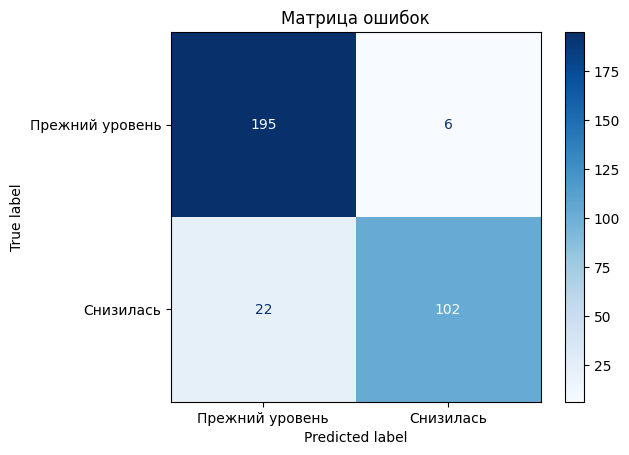

In [99]:
# построим матрицу ошибок с помощью ConfusionMatrixDisplay и confusion_matrix
cm = confusion_matrix(y_test, y_pred_test, labels=['Прежний уровень', 'Снизилась', ])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Прежний уровень', 'Снизилась'])
disp.plot(cmap='Blues')
plt.title('Матрица ошибок')
plt.show()

* Модель **195** раз верно предсказала класс 0 - `Прежний уровень` активности.
* **102** раза верно предсказала класс 1 - `Снизилась`.
* **6** раз ошибочно предсказала класс 1, совершила ошибку False Positive.
* **22** раза ошибочно предсказала класс 0, совершила ошибку False Negative. 

Рассчитаем метрики `precision` и `recall`:

In [100]:
# рассчитаем метрики precision и recall
precision = precision_score(y_test, y_pred_test, pos_label='Снизилась')
recall = recall_score(y_test, y_pred_test, pos_label='Снизилась')

f'Точность precision = {precision:.2f}, точность recall = {recall:.2f}' 

'Точность precision = 0.94, точность recall = 0.82'

* Из всех клиентов, которым модель присвоила класс `Снизилась`, **94 %** действительно снизили активность.
* Из всех клиентов, у которых действительно снизилась активность, **82 %** был правильно найден моделью. 

Нам важно, чтобы модель классификации смогла присвоить 1 большинству объектов этого класса и не пропустила реальных клиентов со сниженной активностью.

Минимизируем критичную для нас ошибку, изменим порог принадлежности к классам:

In [101]:
# подготовим таблицу с вероятностью принадлежности к позитивному классу
data = pd.DataFrame(zip(y_test, y_proba),
                   columns=['y_valid', 'y_proba']).sort_values(by='y_proba', ascending=False)

# выведем 5 первых строк, отсортированных по убыванию
data.head()

,y_valid,y_proba
296,Снизилась,0.999996
271,Снизилась,0.999995
133,Снизилась,0.999994
315,Снизилась,0.999994
251,Снизилась,0.999991


Посмотрим, как модель будет работать при 10 разных порогах. Укажем в `linspace` промежуток пороговых значений: **0.1 - 1.0**.

In [102]:
# укажем в linspace промежуток пороговых значений
thresholds = [round(i,2) for i in np.linspace(0.1,1.0, num=10, endpoint=False)]

# выведем результат
thresholds

[0.1, 0.19, 0.28, 0.37, 0.46, 0.55, 0.64, 0.73, 0.82, 0.91]

Создадим расчётные столбцы с предсказаниями для каждого порога и добавим их в таблицу:

In [103]:
# создадим переменную, которая будет хранить список новых столбцов
columns=[]

# добавим столбцы с новыми предсказаниями в таблицу
for i in thresholds:
    columns.append('y_pred_test'+str(i))
    data['y_pred_test'+str(i)] = data['y_proba'].apply(lambda x: 1 if x >= i else 0)
    
# выведем 5 случайных строк
data.sample(5)

,y_valid,y_proba,y_pred_test0.1,y_pred_test0.19,y_pred_test0.28,y_pred_test0.37,y_pred_test0.46,y_pred_test0.55,y_pred_test0.64,y_pred_test0.73,y_pred_test0.82,y_pred_test0.91
84,Снизилась,0.970477,1,1,1,1,1,1,1,1,1,1
322,Снизилась,0.983704,1,1,1,1,1,1,1,1,1,1
191,Прежний уровень,0.115743,1,0,0,0,0,0,0,0,0,0
135,Снизилась,0.967129,1,1,1,1,1,1,1,1,1,1
67,Снизилась,0.732692,1,1,1,1,1,1,1,1,0,0


Переведём значения `Прежний уровень` и `Снизилась` в числа **0** и **1** в y_valid:

In [104]:
# переведём значения в числа
data['y_valid_num'] = data['y_valid'].apply(lambda x: 1 if x == 'Снизилась' else 0)

# проверим результат
data.head()

,y_valid,y_proba,y_pred_test0.1,y_pred_test0.19,y_pred_test0.28,y_pred_test0.37,y_pred_test0.46,y_pred_test0.55,y_pred_test0.64,y_pred_test0.73,y_pred_test0.82,y_pred_test0.91,y_valid_num
296,Снизилась,0.999996,1,1,1,1,1,1,1,1,1,1,1
271,Снизилась,0.999995,1,1,1,1,1,1,1,1,1,1,1
133,Снизилась,0.999994,1,1,1,1,1,1,1,1,1,1,1
315,Снизилась,0.999994,1,1,1,1,1,1,1,1,1,1,1
251,Снизилась,0.999991,1,1,1,1,1,1,1,1,1,1,1


Посчитаем метрики для каждого порога:

In [105]:
# посчитаем метрики для каждого порога с помощью цикла
for col in columns:
    recall = recall_score(data['y_valid_num'], data[col])
    precision = precision_score(data['y_valid_num'], data[col])
    print(f'Порог {col[-4:]}: Recall = {round(recall, 3)}, Precision = {round(precision, 3)}')

Порог t0.1: Recall = 0.935, Precision = 0.552
Порог 0.19: Recall = 0.887, Precision = 0.71
Порог 0.28: Recall = 0.839, Precision = 0.8
Порог 0.37: Recall = 0.839, Precision = 0.86
Порог 0.46: Recall = 0.831, Precision = 0.928
Порог 0.55: Recall = 0.823, Precision = 0.936
Порог 0.64: Recall = 0.823, Precision = 0.944
Порог 0.73: Recall = 0.79, Precision = 0.961
Порог 0.82: Recall = 0.75, Precision = 0.989
Порог 0.91: Recall = 0.613, Precision = 1.0


Нам нужно учесть как ошибку первого рода, так и второго, отдав более высокий приоритет `recall`, так как важнее минимизировать ошибку второго рода `False Negative`. Выберем порог **0.28** при котором `recall` — **0.839** немного выше, чем `precision` — **0.800**.

Изменим порог и ещё раз сделаем прогноз с помощью обученной модели:

In [106]:
# переведём вероятности в предсказания по новому порогу - 0.28
new_threshold = 0.28
y_new_pred = (y_proba >= new_threshold).astype(int)
y_test_num = y_test.map({'Прежний уровень':0, 'Снизилась':1})

# оценим результат с помощью F-бета
f'F-бета = {fbeta_score(y_test_num, y_new_pred, beta=2, pos_label=1):.2f}'

'F-бета = 0.83'

* Изменение порога почти не повлияло на метрику F-бета: значение снизилось на **1 %**.

**Выводы**:

* Лучше всего справилась модель классификации опорных векторов `SVC` с масштабированием `RobustScaler()`. В первой тройке лучших моделей находится `SVC` со средним значением метрики `ROC-AUC` от **90.60** до **91.40 %**. Остальные шесть лучших моделей — `LogisticRegression` с `ROC-AUC` от **89.94** до **90.02 %** и одна `SVC` — **90 %**.
* Согласно метрике `ROC-AUC`, лучшая модель верно ранжирует классы в **92%** случаев на **тестовых** данных. 
* Для оценки качества модели также использовали метрику `F-бета`. Она позволила учесть `precision` и `recall` в равной степени, отдав больший приоритет важности recall.
* Изменили порог модели, чтобы минимизировать ошибку второго рода. Выбрали порог **0.28**, при котором `recall` — **0.839** немного выше, чем `precision` — **0.800**.
* Изменение порога практически не повлияло на метрику `F-бета`.

<a name="5.3"></a>
### Анализ важности признаков

Оценим важность признаков для лучшей модели и построим график важности с помощью метода SHAP.

Значение Шепли рассчитывают для каждого отдельного наблюдения в выборке. Для этого алгоритм SHAP анализирует все возможные комбинации признаков и выявляет вклад каждого из них в предсказания.

Построим диаграмму `shap.plots.waterfall`, которая показывает, какие признаки и насколько влияют на конкретное предсказание модели:

  0%|          | 0/100 [00:00<?, ?it/s]

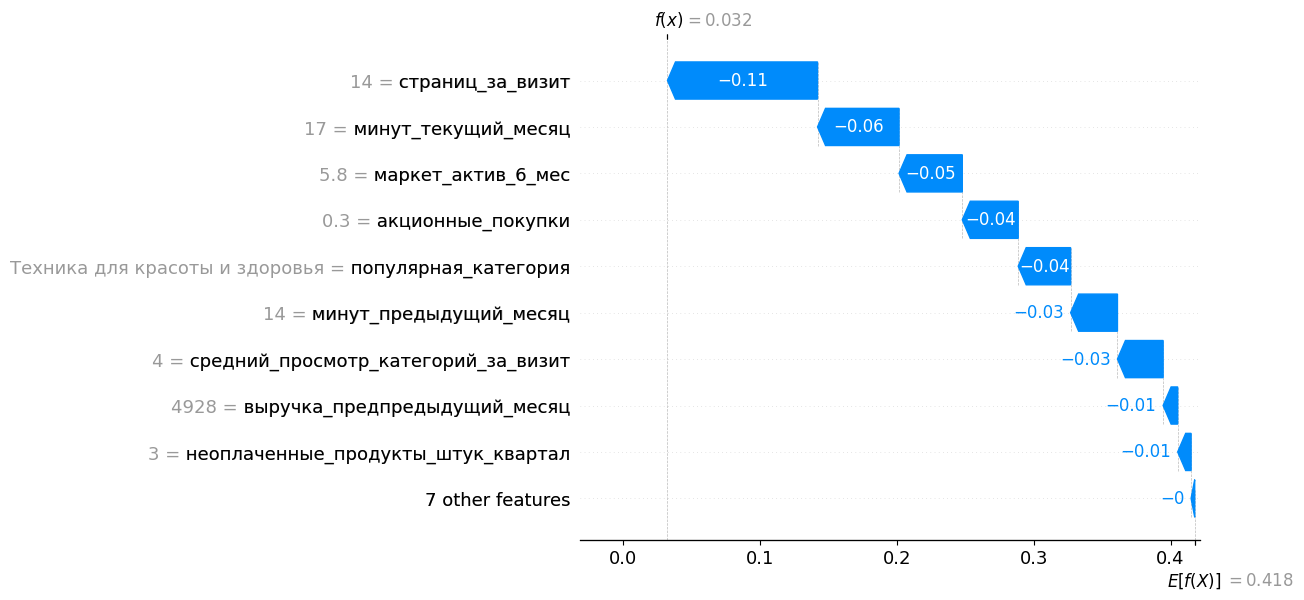

In [107]:
# подготовим выборки как DataFrame 
# возьмём 100 случайных наблюдений из X_train и X_test для ускорения расчетов
X_sample = pd.DataFrame(shap.sample(X_train, 100, random_state=42), columns=X_train.columns)
X_test_sample = pd.DataFrame(shap.sample(X_test, 100, random_state=42), columns=X_test.columns)

# сделаем обертку для predict_proba, чтобы избежать ошибок
# обёртка проверяет, что входные данные - DataFrame
def model_predict_proba(X):
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, columns=X_train.columns)
    return best_model.predict_proba(X)

# инициализируем shap explainer
# используем универсальный метод KernelExplainer
explainer = shap.KernelExplainer(model_predict_proba, X_sample)

# рассчитаем shap-значения для каждого наблюдения в X_test_sample
shap_values = explainer(X_test_sample)

# визуализируем waterfall plot для первого объекта и класса 1
shap.plots.waterfall(shap_values[0, :, 1])

Сделаем **выводы** о значимости признаков для конкретного предсказания:

* Синие блоки показывают признаки, которые снижают вероятность класса **1** в предсказании. На диаграмме отсутствуют красные блоки, значит, модель уверена, что объект принадлежит классу **0**.


* Признаки, которые мало значимы для предсказания модели: `средний_просмотр_категорий_за_визит` (**-0.03**), `минут_предыдущий_месяц` (**-0.03**), `выручка_предпредыдущий_месяц` (**-0.01**), `неоплаченные_продукты_штук_квартал` (**-0.01**).


* Сильнее всего влияют на целевой признак: `страниц_за_визит` (**-0.11**), `минут_текущий_месяц` (**-0.06**), `маркет_актив_6_мес` (**-0.05**), `акционные_покупки` (**-0.04**), `популярная_категория` (**-0.04**).


* Эти наблюдения можно использовать при `моделировании`: можно исключить малозначимые признаки, чтобы упростить модель и ускорить расчеты.


* Эти наблюдения можно использовать при `принятии бизнес-решений`: понимая, какие признаки значительно влияют на прогноз, нужно следить, чтобы они корректно считались и были актуальны. Если пользователи с большим числом просмотренных страниц чаще попадают в класс **0**, это можно использовать в маркетинговых стратегиях. Например, сократить частоту показов рекламы таким пользователям.

С помощью `shap.summary_plot` ознакомимся с влиянием каждого признака на любой прогноз модели:

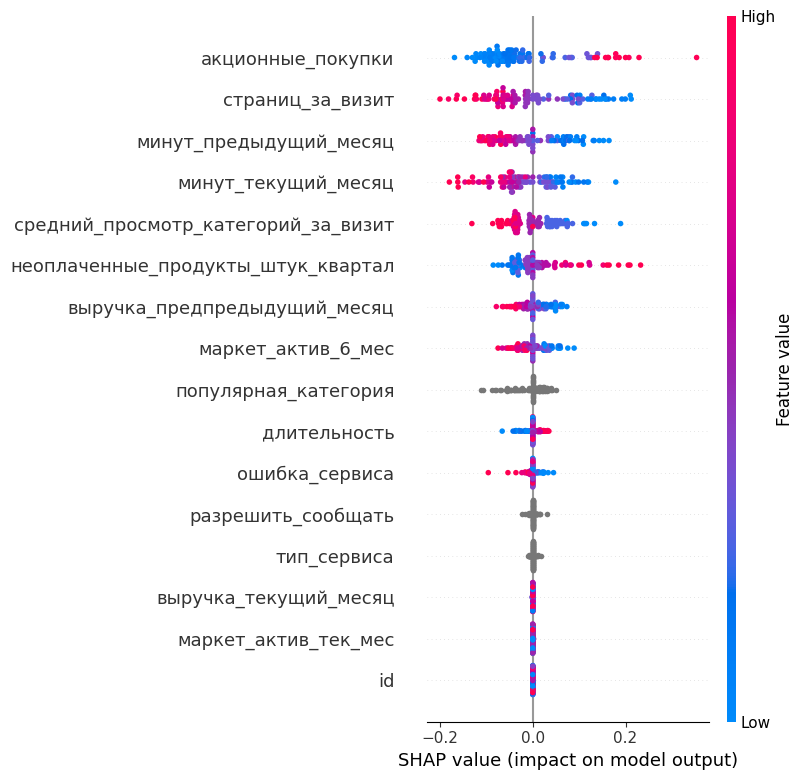

In [108]:
# построим shap.summary_plot
# выведем влияние каждого признака на вероятность класса 1 для каждого объекта
shap.summary_plot(shap_values[:,:,1], X_test_sample)

Сделаем **выводы** о значимости признаков для любого предсказания модели:

* Признаки, которые мало значимы для предсказания модели имеют малое SHAP-значение, т.е. маленькое растяжение по оси x. Они могут быть серыми или бледноокрашенными. В нашем случае это признаки: `id`, `разрешить_сообщать`, `маркет_актив_тек_мес`, `выручка_текущий_месяц`, `тип_сервиса`, `ошибка_сервиса`, `длительность`, `популярная_категория`.


* Сильнее всего влияют на целевой признак: `маркет_актив_6_мес`, `выручка_предпредыдущий_месяц`,  `неоплаченные_продукты_штук_квартал`, `средний_просмотр_категорий_за_визит`, `акционные_покупки`, `минут_текущий_месяц`, `минут_предыдущий_месяц`, `страниц_за_визит`.


* Наибольший вклад дают признаки `акционные_покупки` и `страниц_за_визит`. 


* Розовые точки у признака `акционные_покупки` тянутся вправо и увеличивают вероятность класса 1. Значит, чем выше среднемесячная доля покупок по акции от общего числа покупок, тем выше вероятность снижения активности покупателя.


* Признак `страниц_за_визит` растянут симметрично по оси SHAP влево и вправо. Слева множество красных точек (высокое значение признака), а справа — синих (низкое значение признака). Значит, большое количество просмотренных страниц за визит повышает вероятность предсказания класса **0**, а маленькое количество страниц за визит — повышает вероятность предсказания класса **1** со `сниженной` активностью. 


* **Низкое** `количество просмотренных страниц за визит` можно использовать как сигнал охлаждения интереса у пользователя. Таким пользователям множно направлять напоминание, скидку или делать персонализированное предложение. 


* Эти наблюдения можно использовать при моделировании, исключив малозначимые признаки, чтобы ускорить обучение модели, а также при принятии бизнес-решений: на основе топ-признаков можно выделить новые сегменты клиентов. Признаки с малым SHAP-влиянием можно игнорировать при сегментации.

**Выводы**:

* Для лучшей модели мы оценили влияние признаков на предсказания с помощью SHAP. Метод позволяет проанализировать вклад каждого признака как в отдельные предсказания (через `waterfall plot`), так и в предсказания модели в целом (через `summary plot`).


* Самые влиятельные признаки — `акционные_покупки` и `страниц_за_визит`. Чем выше среднемесячная доля покупок по акции от общего числа покупок, тем выше вероятность снижения активности покупателя. Большое количество просмотренных страниц за визит повышает вероятность предсказания класса `прежний уровень`, а маленькое количество страниц за визит — повышает вероятность предсказания класса `снизилась`. 


* Наблюдения можно использовать при моделировании и принятии бизнес-решений: для исключения малозначимых признаков и ускорения обучения модели, сегментации клиентов.

<a name="6"></a>
## Сегментация покупателей

Выполним сегментацию покупателей. Используем результаты моделирования и данные о прибыльности покупателей.

Согласно диаграмме `shap.summary_plot` один из самых влиятельных признаков — `страниц_за_визит` . Используем его как главный поведенческий показатель, а также `выручку` как второй уровень разбиения.

Выделим 9 ключевых сегментов:

1. **Мало** просмотренных страниц + **низкая** выручка


2. **Мало** просмотренных страниц + **высокая** выручка


3. **Мало** просмотренных страниц + **умеренная** выручка


4. **Много** просмотренных страниц + **низкая** выручка


5. **Много** просмотренных страниц + **высокая** выручка


6. **Много** просмотренных страниц + **умеренная** выручка


7. **Умеренное** количество просмотренных страниц + **низкая** выручка


8. **Умеренное** количество просмотренных страниц + **высокая** выручка


9. **Умеренное** количество просмотренных страниц + **умеренная** выручка

Определим, какое количество страниц войдёт в сегменты **мало**, **много** и **умеренно**. Разобъём данные в столбце на части по квартилям (25%, 50%, 75%): 

In [109]:
# вернём значение признака, ниже которого находится заданный процент данных с помощью quantile()
file_money_time_3_month['страниц_за_визит'].quantile([0.25, 0.5, 0.75])

0.25     5.0
0.50     8.0
0.75    11.0
Name: страниц_за_визит, dtype: float64

* Количество страниц равное или меньше 5 отнесём к сегменту **Мало**.
* Количество страниц равное или больше 11 отнесём к сегменту **Много**.
* Промежуточные значения от 6 до 10 отнесём к сегменту **Умеренно**.

Найдём медианное значение выручки за 3 месяца для каждого клиента и добавим в таблицу новый столбец:

In [110]:
# добавим столбец с медианной выручкой для каждого клиента за 3 месяца
file_money_time_3_month['выручка_медиана'] = (
    file_money_time_3_month[['выручка_предпредыдущий_месяц', 'выручка_предыдущий_месяц', 'выручка_текущий_месяц']]
    .median(axis=1)
)

# выведем 10 первых строк таблицы
file_money_time_3_month.head(10)

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предпредыдущий_месяц,выручка_предыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц,выручка_медиана
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12.0,10.0,4971.6
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8.0,13.0,5058.4
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11.0,13.0,6158.0
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8.0,11.0,5807.5
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10.0,10.0,5124.0
5,215354,Снизилась,стандарт,да,5.1,3,431,0.23,Косметика и аксесуары,2,3,7,2,4503.0,5685.0,5869.6,11.0,12.0,5685.0
6,215355,Снизилась,стандарт,нет,4.7,4,284,0.17,Товары для детей,5,1,6,4,4749.0,3263.0,3772.6,12.0,10.0,3772.6
7,215356,Снизилась,стандарт,да,4.2,4,192,0.14,Косметика и аксесуары,2,2,1,3,4433.0,4146.5,4566.4,6.0,7.0,4433.0
8,215358,Снизилась,стандарт,да,4.7,4,450,0.13,Домашний текстиль,4,2,6,4,4727.0,3488.0,4209.5,14.0,10.0,4209.5
9,215360,Снизилась,премиум,да,3.9,3,623,0.35,Кухонная посуда,3,1,4,7,5555.0,5304.5,5834.9,9.0,6.0,5555.0


Проверим новый столбец на наличие выбросов:

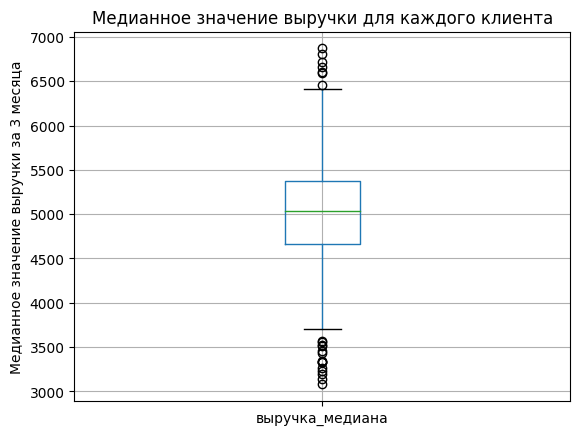

In [111]:
# вызовем функцию для построения диаграммы размаха
boxplot_creation(file_money_time_3_month, 'выручка_медиана', 'Медианное значение выручки для каждого клиента', 'Медианное значение выручки за 3 месяца')

* Диаграмма показывает наличие выбросов у верхнего и нижнего "уса", приблизительно от отметки **3000** до **3600** и от **6400** до **6900**.

Рассчитаем границы нормального размаха:

In [112]:
# сохраним в переменные первый (25%) и третий (75%) квартили по столбцу
Q1 = file_money_time_3_month['выручка_медиана'].quantile(0.25)
Q3 = file_money_time_3_month['выручка_медиана'].quantile(0.75)

# рассчитаем межквартильный размах
IQR = Q3 - Q1

# вычислим верхнюю и нижнюю границы нормального размаха
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

# используем print, чтобы перенести строку с помошью \n
print(f"Верхняя граница выбросов = {upper_limit}\nНижняя граница выбросов = {lower_limit}")

Верхняя граница выбросов = 6448.75
Нижняя граница выбросов = 3594.75


Отфильтруем данные в столбце по верхней и нижней границам нормального размаха:

In [113]:
# отфильтруем данные в столбце с помощью query()
file_money_time_3_month = file_money_time_3_month.query('выручка_медиана >= 3594.75 and выручка_медиана <= 6448.75')

# проверим результат
file_money_time_3_month['выручка_медиана'].head(10).sort_values()

6    3772.6
8    4209.5
7    4433.0
0    4971.6
1    5058.4
4    5124.0
9    5555.0
5    5685.0
3    5807.5
2    6158.0
Name: выручка_медиана, dtype: float64

In [114]:
# проверим результат
file_money_time_3_month['выручка_медиана'].head(10).sort_values(ascending=False)

2    6158.0
3    5807.5
5    5685.0
9    5555.0
4    5124.0
1    5058.4
0    4971.6
7    4433.0
8    4209.5
6    3772.6
Name: выручка_медиана, dtype: float64

Определим, какие диапазоны выручки войдут в категории **низкой**, **высокой** и **умеренной** выручки. Разделим данные на части по квартилям (25%, 50%, 75%):

In [115]:
# вернём значение признака, ниже которого находится заданный процент данных с помощью quantile()
file_money_time_3_month['выручка_медиана'].quantile([0.25, 0.5, 0.75])

0.25    4677.5
0.50    5035.5
0.75    5375.5
Name: выручка_медиана, dtype: float64

* К категории **низкой** выручки отнесём значения, которые равны или меньше **4677.5** рублей.
* К категории **высокой** выручки отнесём значения, которые равны или больше **5375.5** рублей.
* Промежуточные значения от **4677.5** до **5375.5** рублей отнесём к **умеренной** выручке.

Сегментируем клиентов и добавим новые столбцы в таблицу:

In [116]:
# напишем функцию для сегментации клиентов
def segmentation_clients(row):
    pages = row['страниц_за_визит']
    revenue = row['выручка_медиана']

# сегментация по страницам
    if pages <= 5:
        pages_category = "Мало страниц"
    elif 5 < pages < 11:
        pages_category = "Умеренное количество страниц"
    else:
        pages_category = "Много страниц"
    
# сегментация по выручке
    if revenue <= 4677.5:
        revenue_category = "Низкая выручка"
    elif 4677.5 < revenue < 5375.5:
        revenue_category = "Умеренная выручка"
    else:
        revenue_category = "Высокая выручка"
    
    return f'{pages_category} + {revenue_category}'

# применим функцию с помощью apply, добавим новый столбец в таблицу
file_money_time_3_month['сегмент'] = file_money_time_3_month.apply(segmentation_clients, axis=1)

In [117]:
# проверим результат, выведем первые 20 строк
file_money_time_3_month[['id','страниц_за_визит','выручка_медиана','сегмент']].head(20)

,id,страниц_за_визит,выручка_медиана,сегмент
0,215349,5,4971.6,Мало страниц + Умеренная выручка
1,215350,5,5058.4,Мало страниц + Умеренная выручка
2,215351,4,6158.0,Мало страниц + Высокая выручка
3,215352,2,5807.5,Мало страниц + Высокая выручка
4,215353,4,5124.0,Мало страниц + Умеренная выручка
5,215354,2,5685.0,Мало страниц + Высокая выручка
6,215355,4,3772.6,Мало страниц + Низкая выручка
7,215356,3,4433.0,Мало страниц + Низкая выручка
8,215358,4,4209.5,Мало страниц + Низкая выручка
9,215360,7,5555.0,Умеренное количество страниц + Высокая выручка


Для более комфортного восприятия создадим отдельную таблицу с информацией о сегментах: c `количеством клиентов`, `медианным значением страниц` и `выручки` для каждого сегмента.

In [118]:
# создадим таблицу с информацией о каждом сегменте
# подсчитаем количество id в каждом сегменте
# подсчитаем медианное значение количества страниц за визит в каждом сегменте
# подсчитаем медианное значение выручки в каждом сегменте
segmentation_client = (
    file_money_time_3_month
    .groupby('сегмент')
    .agg(
        количество_клиентов=('id','count'),
        медиана_страниц_за_визит=('страниц_за_визит', 'median'),
        медиана_выручки=('выручка_медиана', 'median')
    )
)

In [119]:
# выведем итоговый результат
segmentation_client

,количество_клиентов,медиана_страниц_за_визит,медиана_выручки
сегмент,,,
Мало страниц + Высокая выручка,107,4.0,5781.70
Мало страниц + Низкая выручка,104,4.0,4382.60
Мало страниц + Умеренная выручка,150,4.0,5055.70
Много страниц + Высокая выручка,74,13.0,5588.75
Много страниц + Низкая выручка,82,12.0,4467.25
Много страниц + Умеренная выручка,212,13.0,5003.25
Умеренное количество страниц + Высокая выручка,138,7.5,5635.50
Умеренное количество страниц + Низкая выручка,133,8.0,4486.00
Умеренное количество страниц + Умеренная выручка,275,8.0,5035.50


Выберем группу покупателей `Мало страниц + Низкая выручка` и изучим её более детально. Проведём аналитическое и графическое исследование этой группы.

Посмотрим на распределение клиентов сегмента по `типу_сервиса`:

In [120]:
# сохраним в переменной информацию о сегменте Мало страниц + Низкая выручка
few_pages_revenue = file_money_time_3_month.query('сегмент == "Мало страниц + Низкая выручка"')

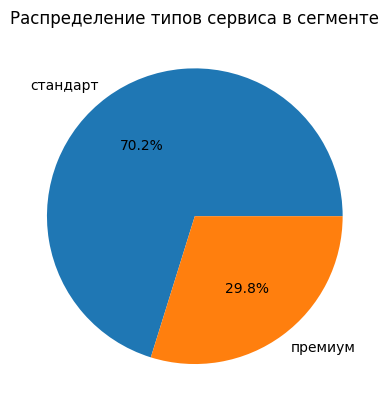

In [121]:
# напишем функцию для построения круговой диаграммы
def pie_creation(column, title):
    column_value_counts = few_pages_revenue[column].value_counts()
    plt.pie(
    column_value_counts,
    labels=column_value_counts.index,
    autopct='%1.1f%%')
    plt.title(title)
    plt.show()

# вызовем функцию
pie_creation('тип_сервиса', 'Распределение типов сервиса в сегменте')

* Большинство клиентов в сегменте `Мало страниц + Низкая выручка` используют `стандартный` тип сервиса — **70.2 %**

Посмотрим на распределение клиентов сегмента по `разрешению получать дополнительные предложения`:

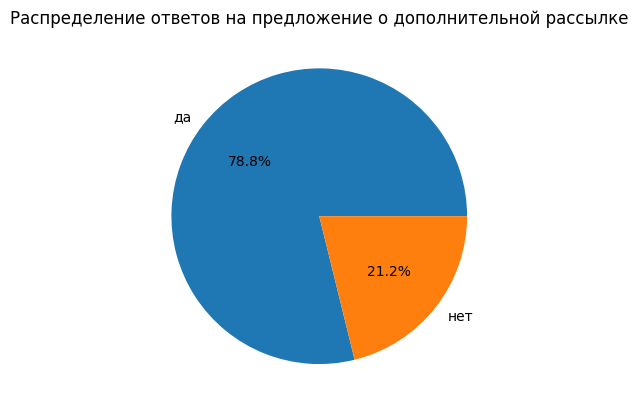

In [122]:
# вызовем функцию
pie_creation('разрешить_сообщать', 'Распределение ответов на предложение о дополнительной рассылке')

* Большинство клиентов в сегменте дают разрешение на получение дополнительных предложений — **78.8 %**

Ознакомимся с распределением популярных категорий товаров в сегменте:

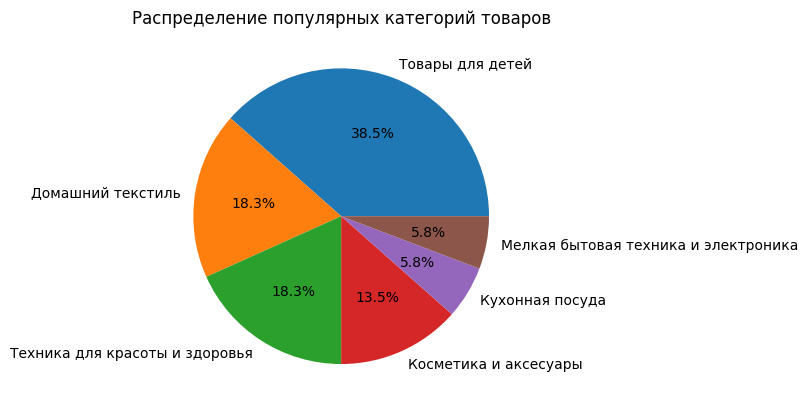

In [123]:
# вызовем функцию
pie_creation('популярная_категория', 'Распределение популярных категорий товаров')

* Самая популярная категория товаров среди покупателей в сегменте  — `Товары для детей` (**38.5%**), `Домашний текстиль` (**18.3%**), `Техника для красоты и здоровья` (**18.3%**).

* Наименее популярные категории — `Мелкая бытовая техника и электроника` (**5.8%**) и `Кухонная посуда` (**5.8%**).

Рассчитаем среднее доли покупок по акции и среднее количества маркетинговых коммуникаций в текущем месяце, а также медианное значение количества дней с момента регистрации клиента на сайте:

In [124]:
# рассчитаем среднее доли покупок по акции
# рассчитаем среднее значение маркетинговых коммуникаций в текущем месяце
# рассчитаем медиану количества дней с момента регистрации покупателя на сайте
agg = few_pages_revenue.groupby('сегмент').agg({
    'акционные_покупки':'mean',
    'маркет_актив_тек_мес': 'mean',
    'длительность':'median'
}).reset_index()

# переименуем столбцы
agg.columns = ['название сегмента', 'доля_акционных_покупок',  'среднее_значение_маркетинг_тек_мес', 'медиана_длительность']

# выведем результат
agg

,название сегмента,доля_акционных_покупок,среднее_значение_маркетинг_тек_мес,медиана_длительность
0,Мало страниц + Низкая выручка,0.471635,4.009615,564.5


Предложения по работе с сегментом для увеличения покупательской активности:

* Клиенты этого сегмента совершают около **47%** покупок по акциям и проявляют особый интерес к категориям `«Товары для детей»`, `«Домашний текстиль»` и `«Техника для красоты и здоровья»`. При этом они охотно дают согласие на получение дополнительных предложений по электронной почте. Рекомендуется предложить им эксклюзивные скидки или акции именно на самые востребованные категории и организовать персонализированную рассылку с информацией о специальных предложениях.

**Выводы**:

* Мы сегментировали покупателей по ключевым признакам — количеству просмотренных страниц за визит и медианной выручке за три месяца. Выделили 9 сегментов покупателей.


* Выбрали сегмент покупателей `Мало страниц + Низкая выручка` для более детального исследования.


* Предложили сделать клиентам эксклюзивные скидки и акции на товары из популярных категорий, запустить тематические email-рассылки с информацией о специальных предложениях и новинках. Клиенты этого сегмента совершают около 47% покупок по акциям, проявляют особый интерес к категориям `«Товары для детей»`, `«Домашний текстиль»` и `«Техника для красоты и здоровья»`, охотно дают согласие на получение дополнительных предложений о товаре.   

<a name="7"></a>
## Общий вывод

* Мы выполнили поставленную задачу — разработали решение, которое позволит персонализировать предложения постоянным клиентам интернет-магазина «В один клик», чтобы увеличить их покупательскую активность.


* Для этого мы построили модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца, включили в исследование дополнительные данные финансового департамента о прибыльности клиента, выделили сегменты покупателей, используя данные модели и данные о прибыльности клиентов, разработали персонализированные предложения для покупателей.


* Мы ознакомились со структурой данных в таблицах. Предварительно заметили в данных следующие проблемы: разное оформление названий столбцов, орфографические ошибки, неявные дубликаты, запятая в качестве разделителя десятичных значений. В результате предобработки переименовали столбцы, изменили типы данных, обработали неявные дубликаты.


* Мы создали пайплайн для поиска лучшей модели. Для автоматического подбора гиперпараметров использовали перебор по сетке — `GridSearchCV`. При подборе гиперпараметров оценивали предсказания моделей с помощью метрики `ROC-AUC`.


* Эффективнее всего себя проявила модель классификации опорных векторов `SVC` с масштабированием `RobustScaler()`. Согласно метрике `ROC-AUC`, лучшая модель верно ранжирует классы в **92 %** случаев на **тестовых** данных.


* Выделили **9** сегментов покупателей. Для более детального исследования выбрали сегмент покупателей `Мало страниц + Низкая выручка`:
1. Предложили сделать клиентам эксклюзивные скидки и акции на товары из популярных категорий, запустить тематические email-рассылки с информацией о специальных предложениях и новинках. 


2. Дополнительно можно предложить ввести напоминания о неоплаченных товарах в корзине. Поскольку клиенты редко посещают сайт магазина и приносят низкую выручку, можно предположить, что они не завершают покупку из-за отсутствия напоминаний.


3. Также можно предложить скидку при добавлении товара в корзину при условии покупки в ближайшее время.